____
# Sensitivity to stain and vorticity


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon
from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_variance, compute_variance_groupby, compute_variance

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_________
# Vorticity and Strain maps

In [2]:
product = 'swot2km'
dss3 = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, 'general', f'pass3_{product}_general.nc'))
dss16 = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, 'general', f'pass16_{product}_general.nc'))

dss3 = xr.merge([dss3,  xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, 'diff_only', f'pass3_{product}_diff_only.nc'))], compat='override')
dss16 = xr.merge([dss16, xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, 'diff_only', f'pass16_{product}_diff_only.nc'))], compat='override')

dss3 = dss3.where(dss3.distance_to_coast>20e3, drop=True)
dss16 = dss16.where(dss16.distance_to_coast>20e3, drop=True)

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute 

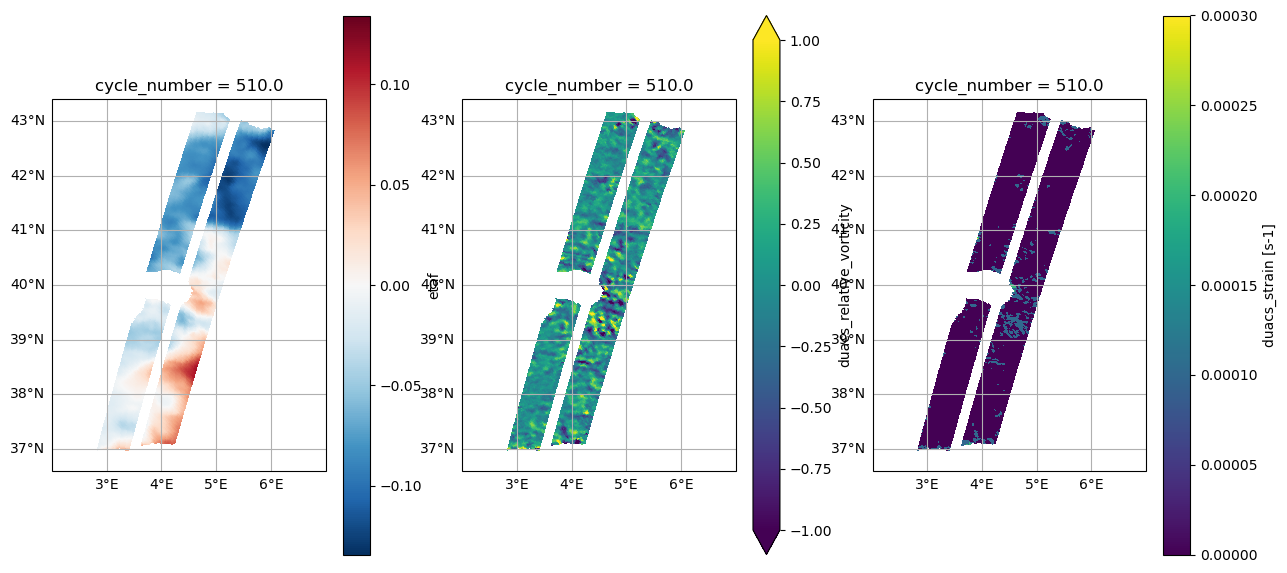

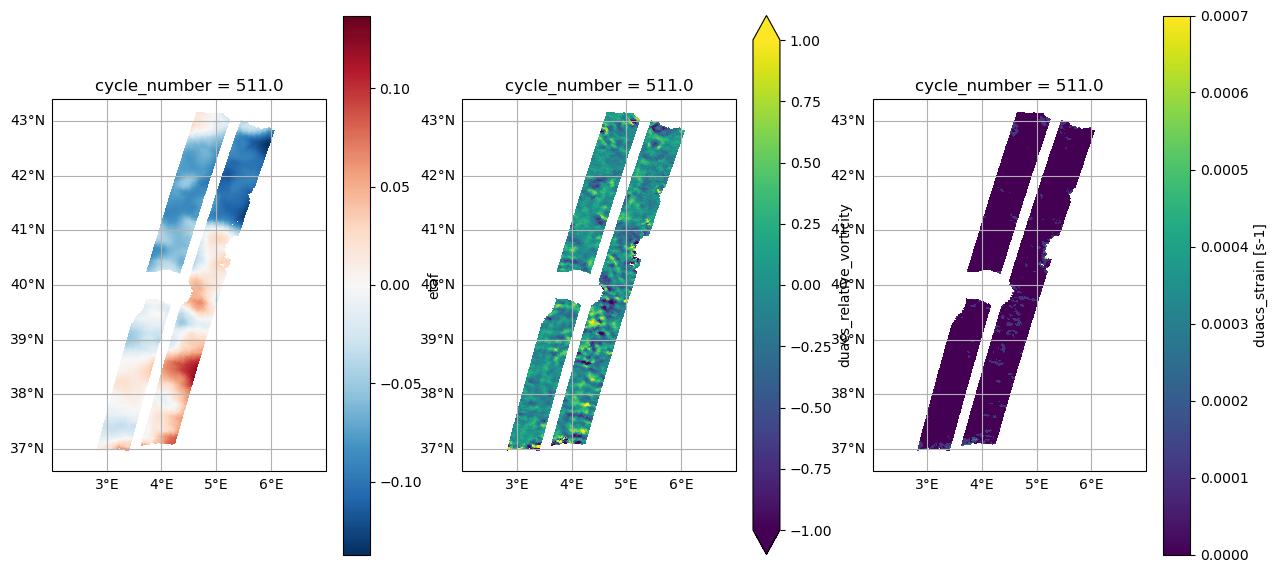

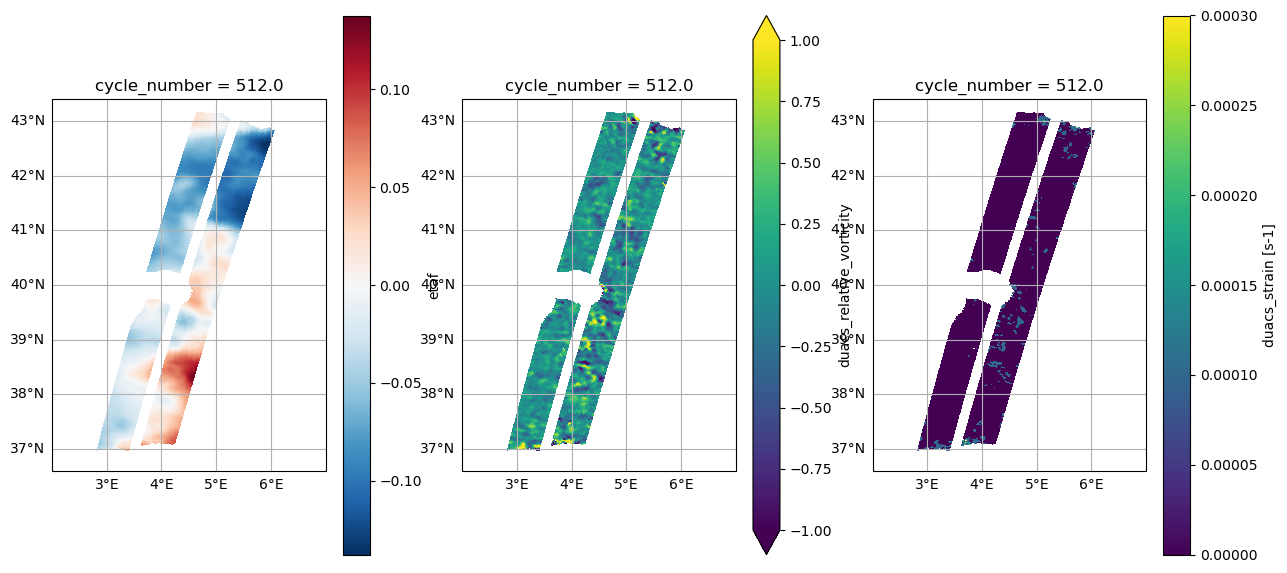

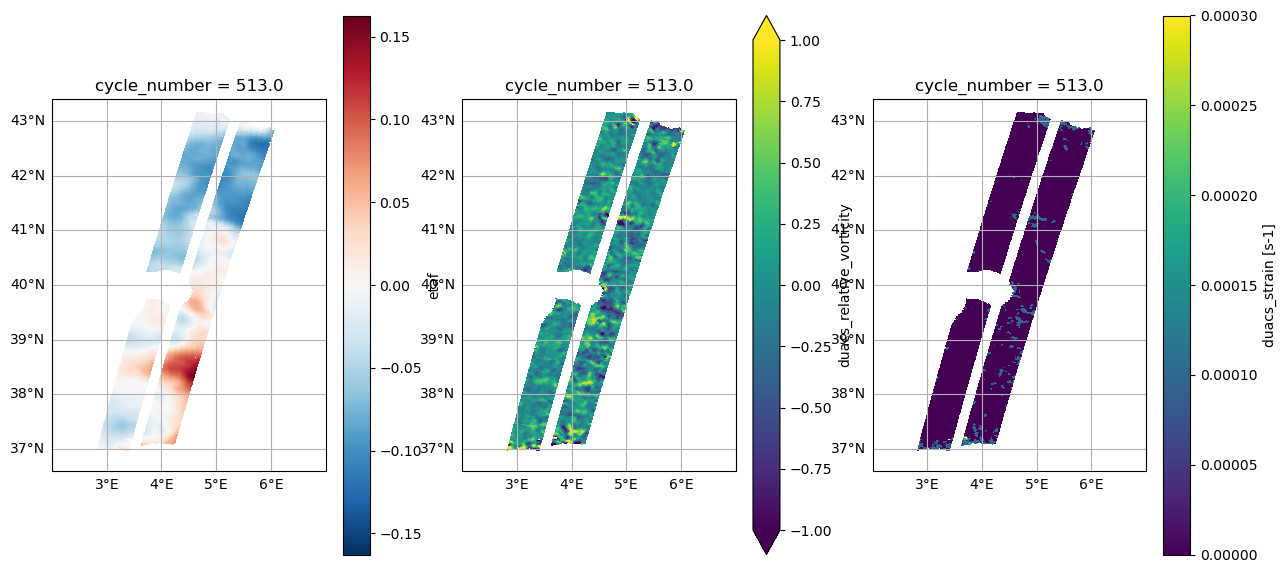

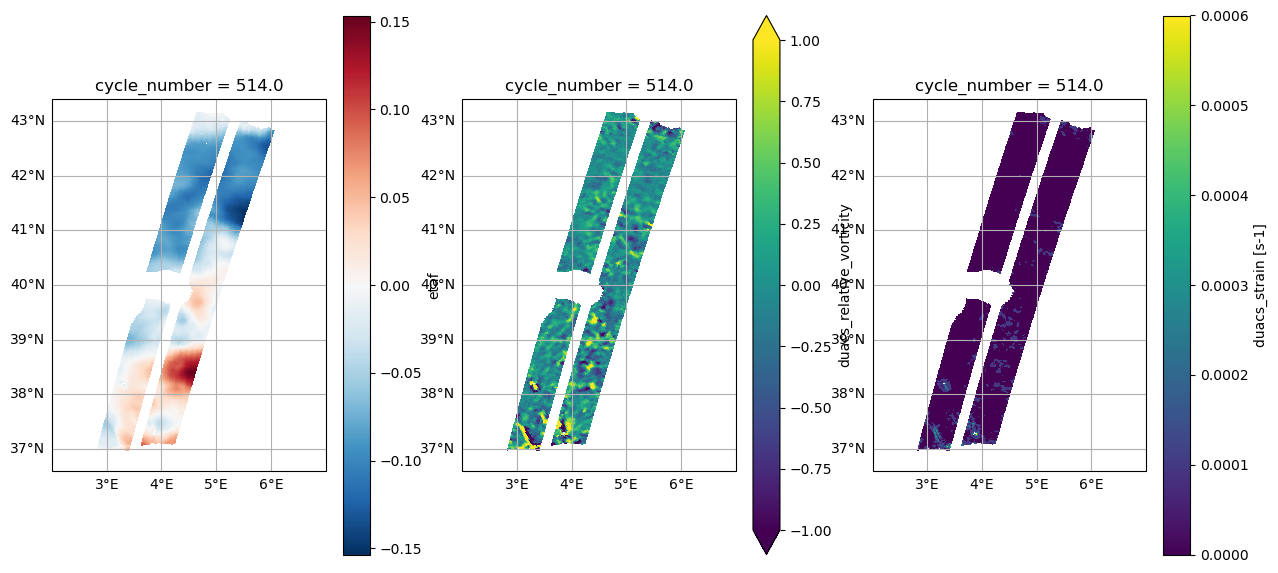

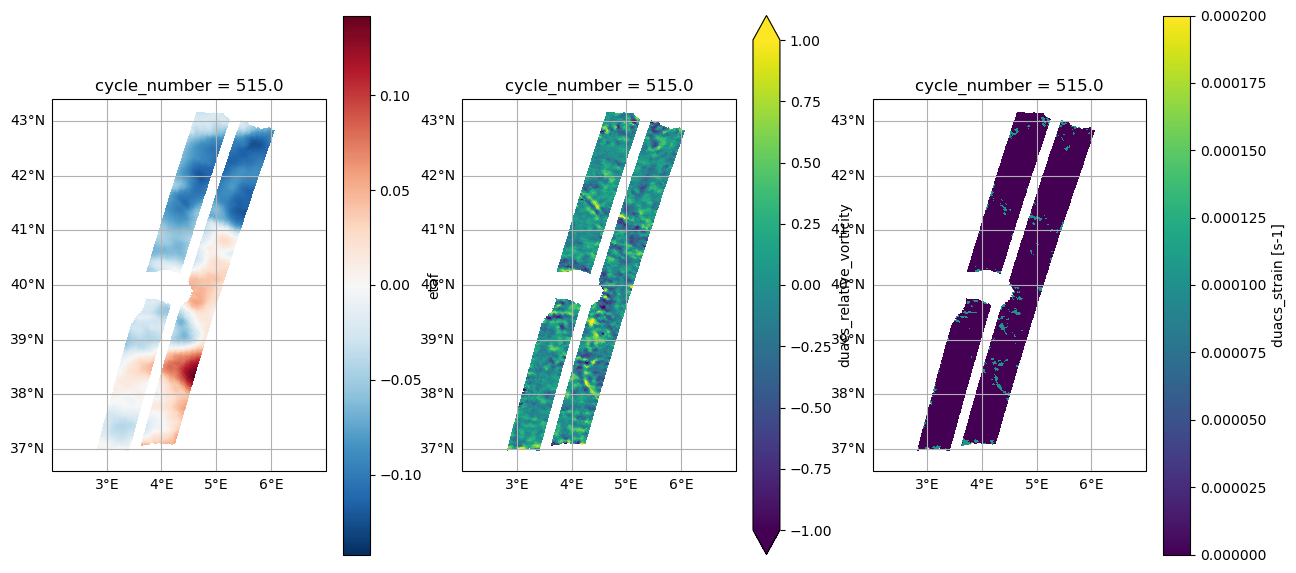

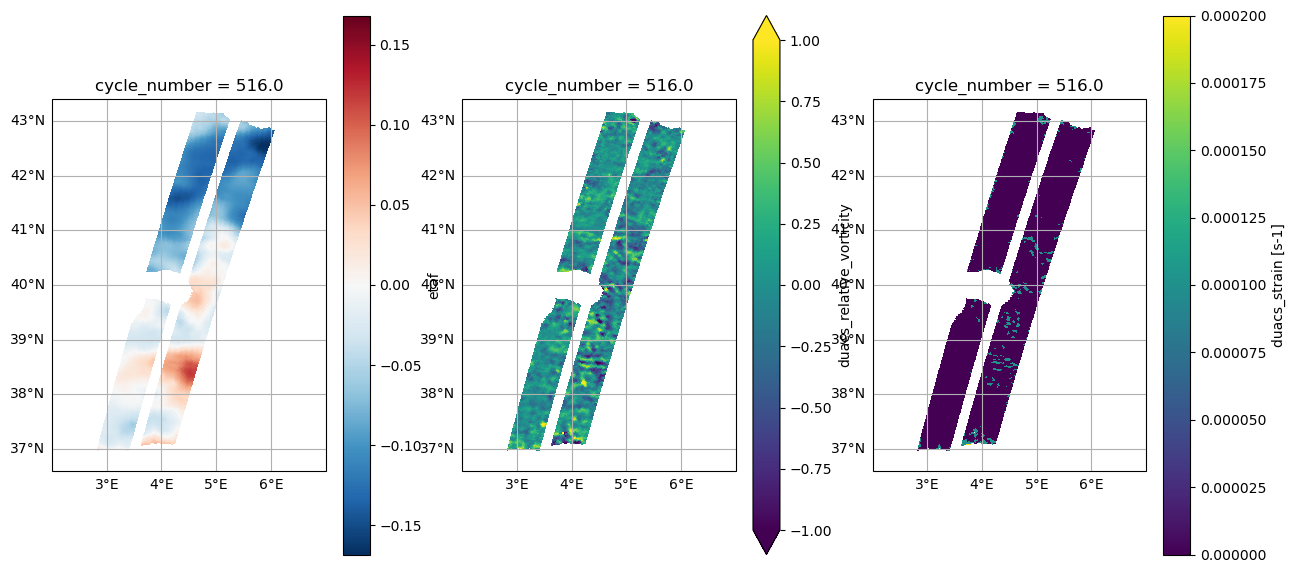

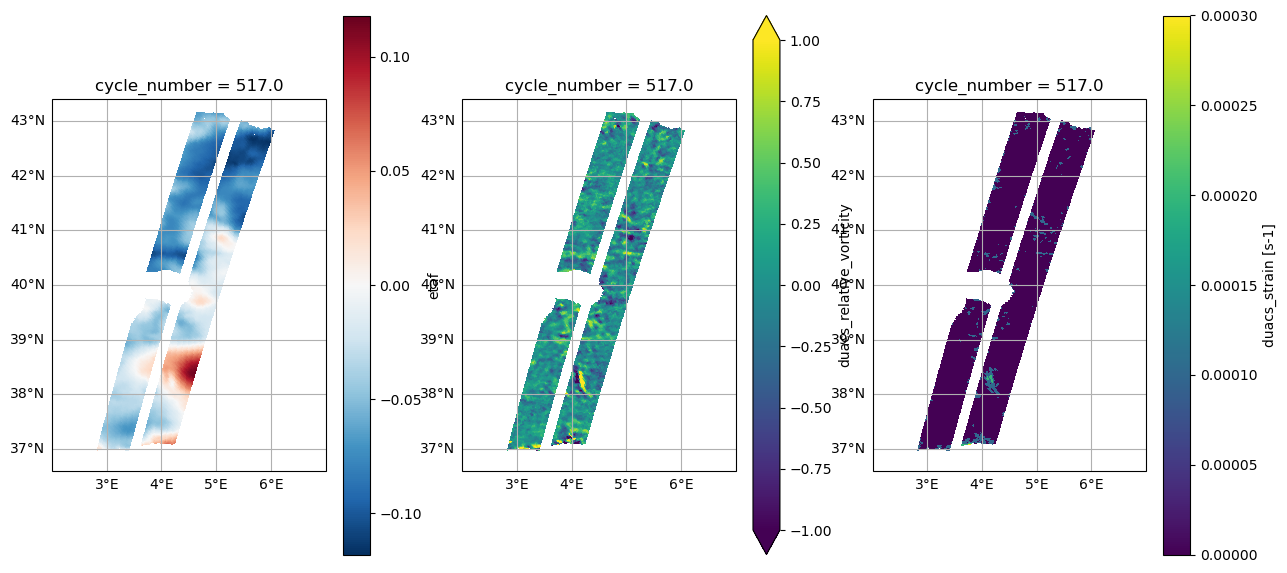

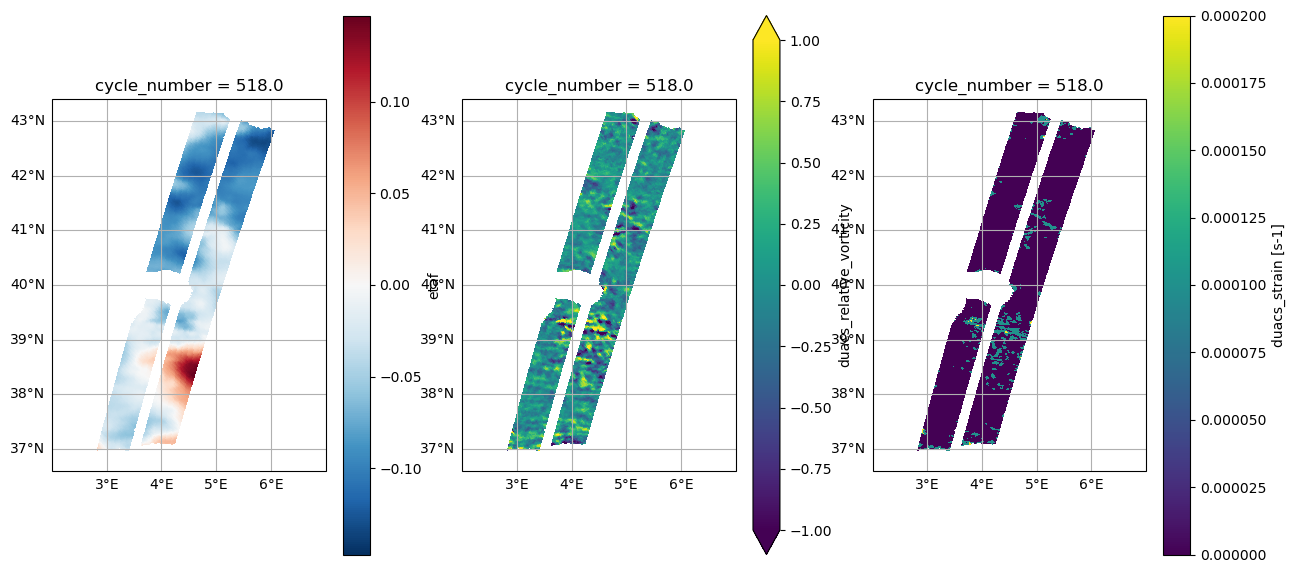

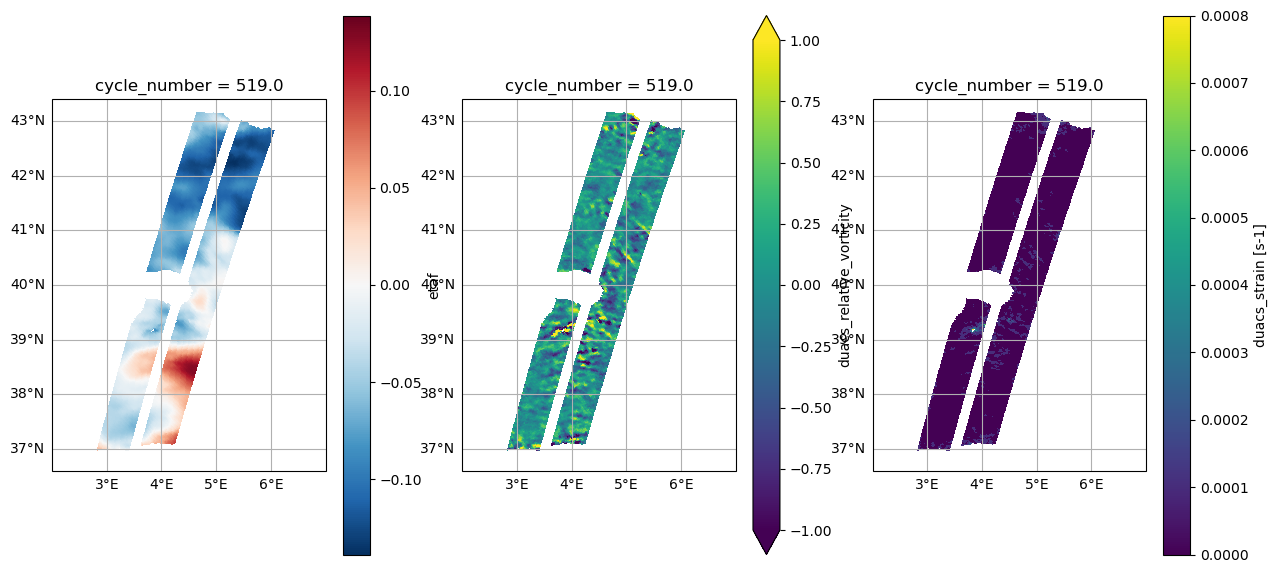

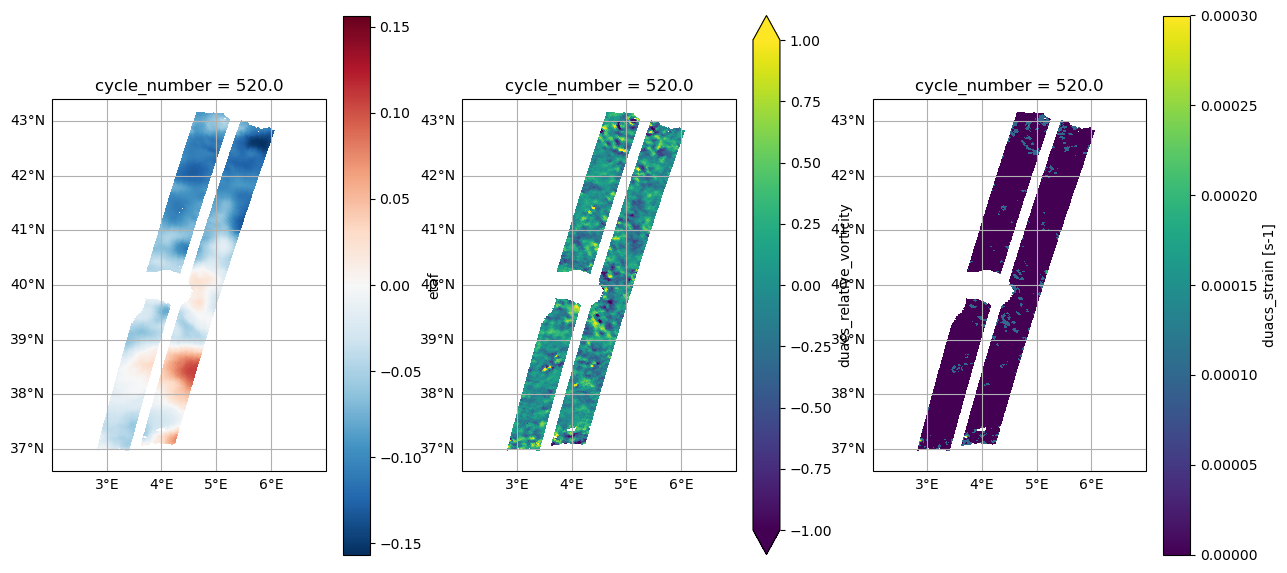

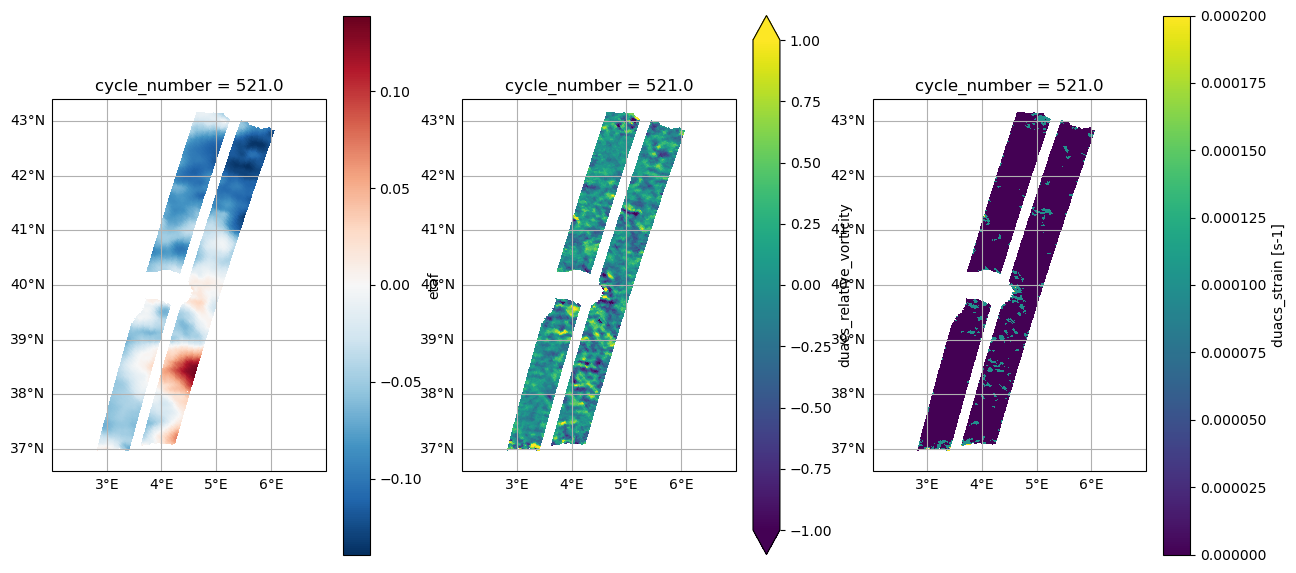

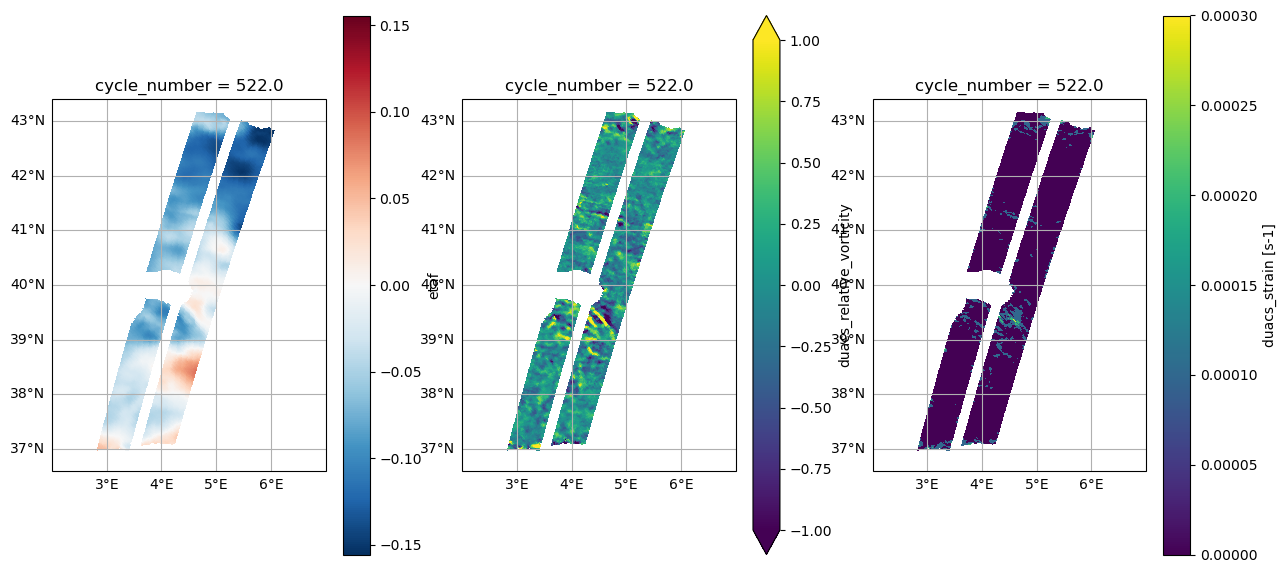

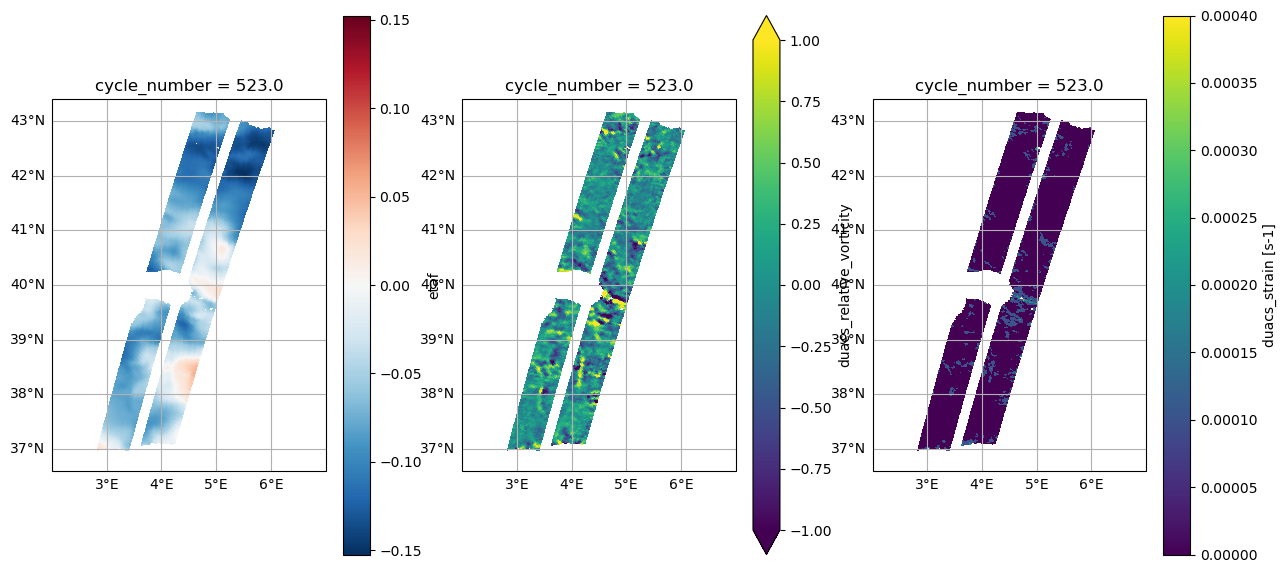

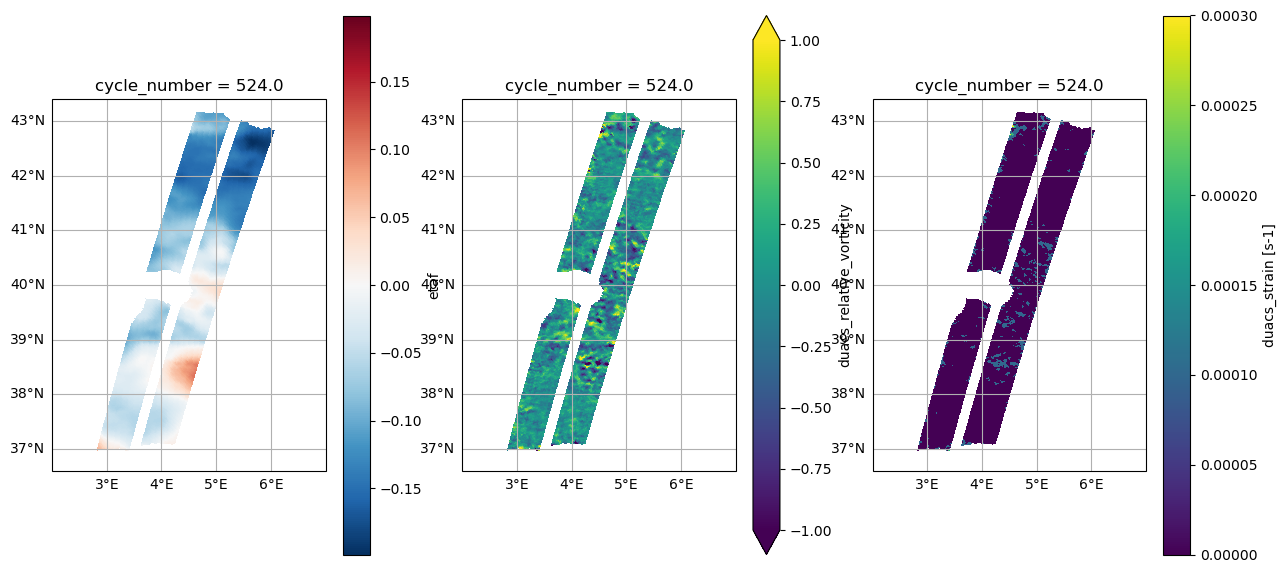

In [3]:
for i in range(510, 525, 1):
    bbox = [2, 7, 36.6, 43.4]
    
    fig, axs = plt.subplots(1, 3, figsize=(15,7), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()), sharey=True)

    ax=axs[0]
    kw = dict(transform=crs)
    dss3.etaf.sel(cycle_number=i).plot(x='longitude', y='latitude',ax=ax, **kw)

    ax=axs[1]
    kw = dict(transform=crs, vmin = -1, vmax = 1)
    dss3.duacs_relative_vorticity.sel(cycle_number=i).plot(x='longitude', y='latitude',ax=ax, **kw)
    
    ax=axs[2]
    #kw = dict(vmin = 0, vmax = 1e-4)
    dss3.duacs_strain.sel(cycle_number=i).plot(x='longitude', y='latitude', ax=ax)#, **kw)
    
    for ax in axs :
        ax.set_extent(bbox)
        gl = ax.gridlines(draw_labels=True,)
        gl.xlabels_top = False
        gl.ylabels_right = False

In [4]:
dss3_ = dss3.sel(cycle_number= slice(500, 515))

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute 

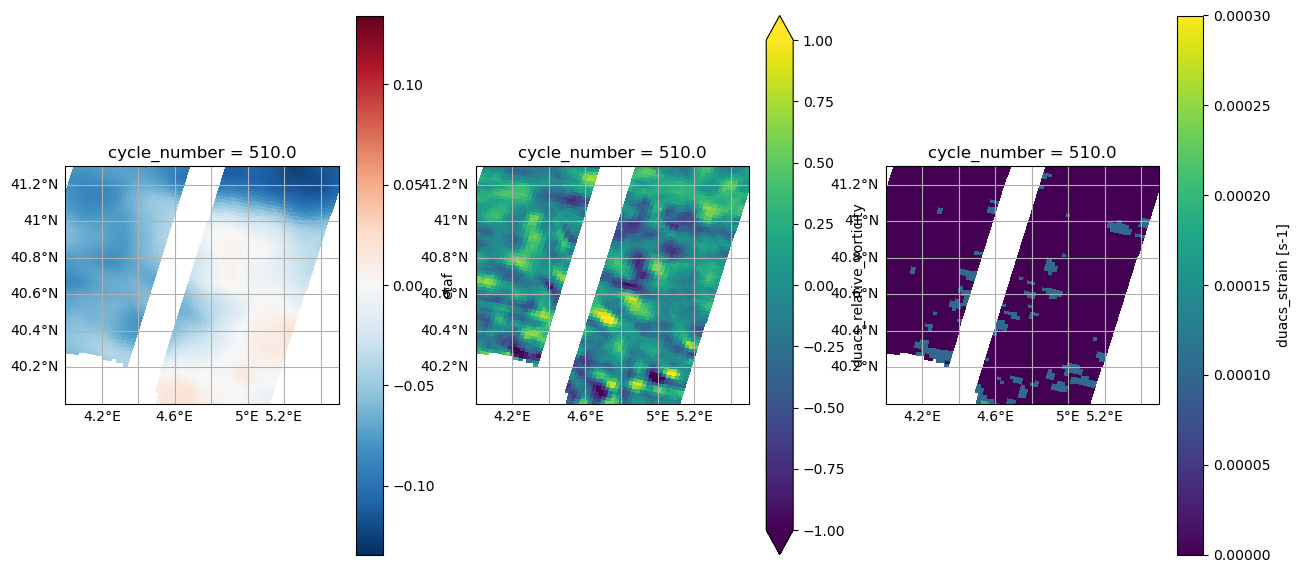

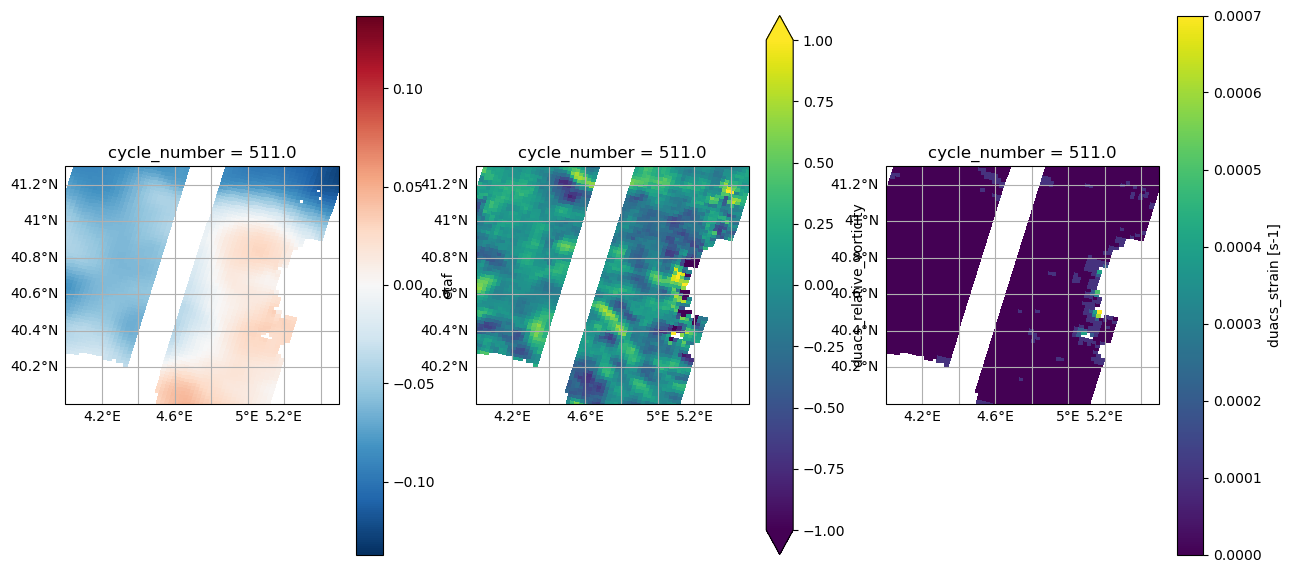

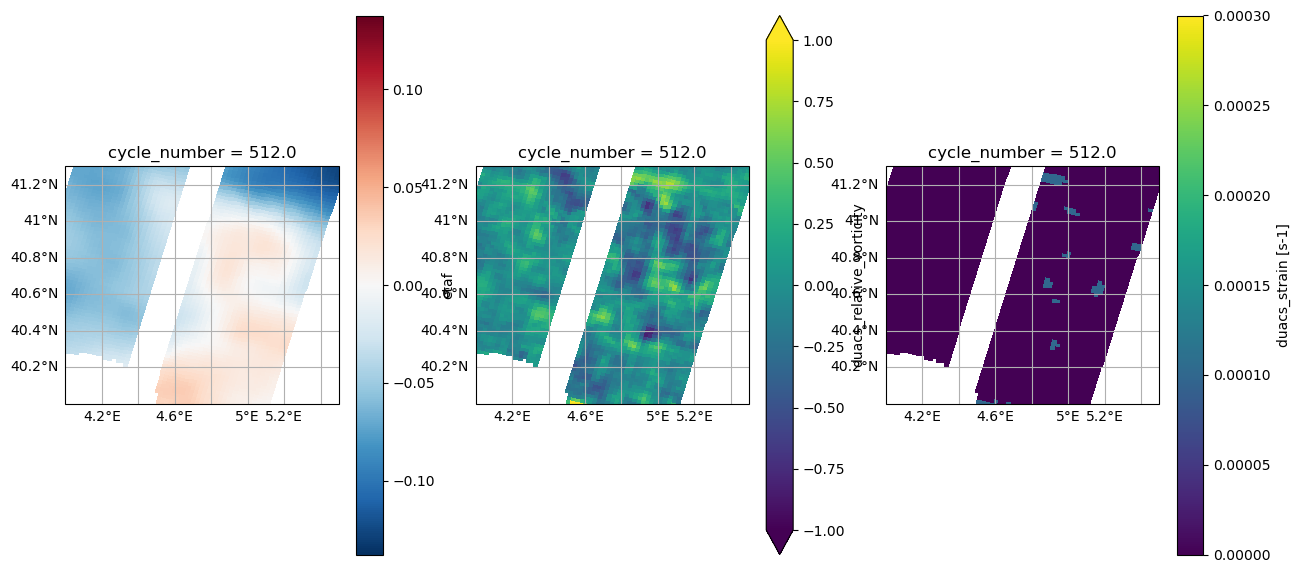

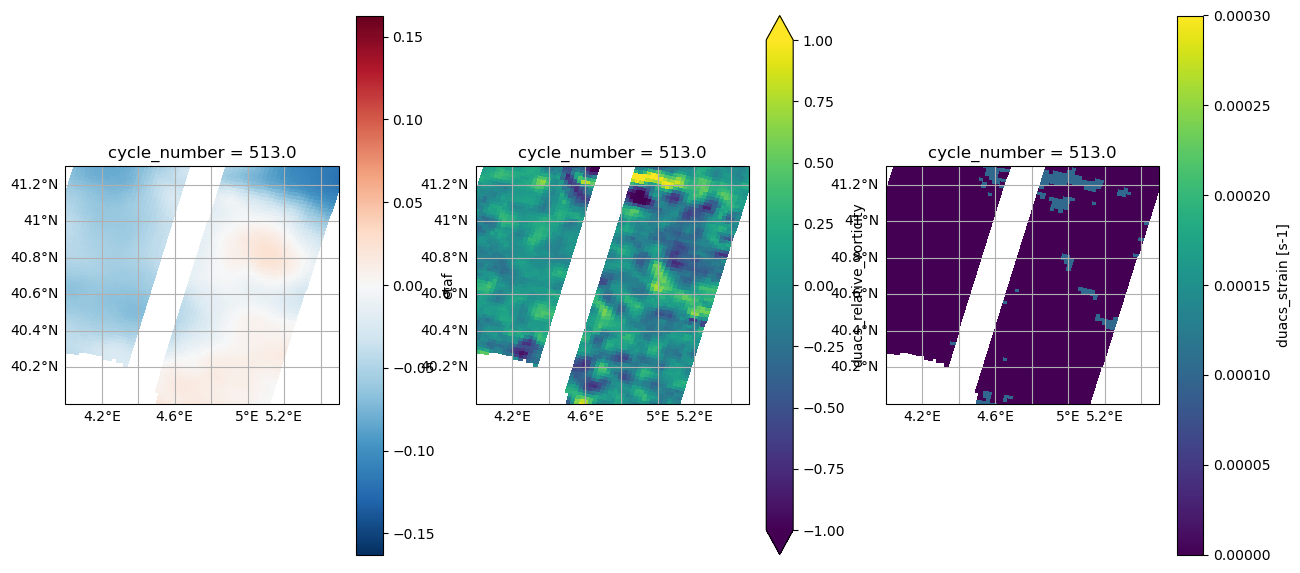

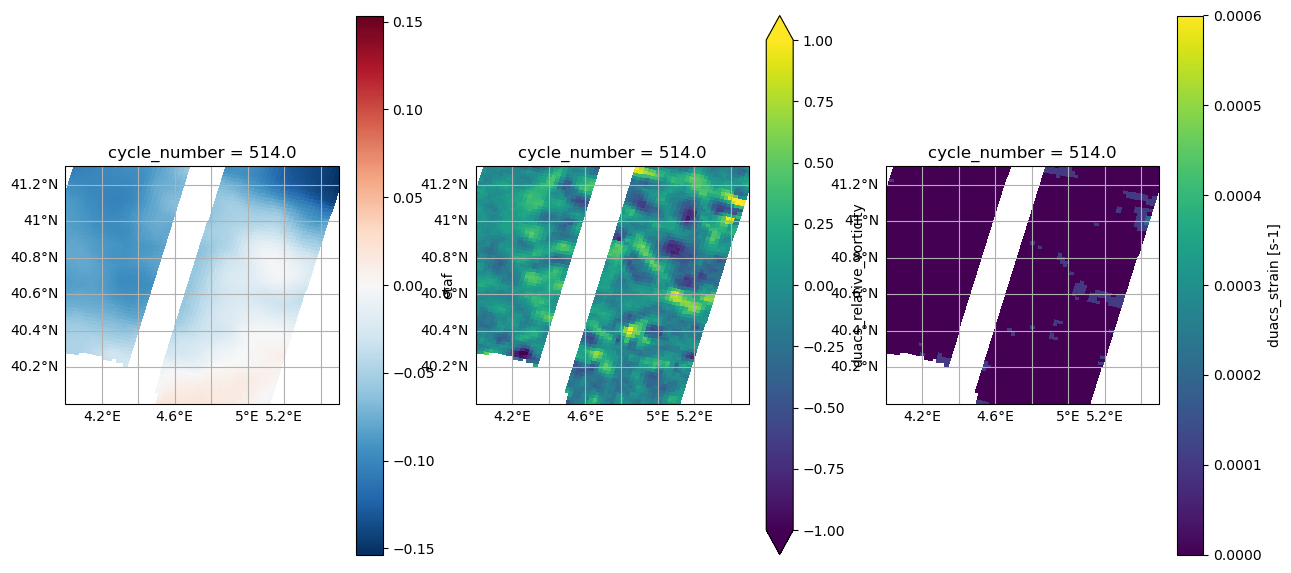

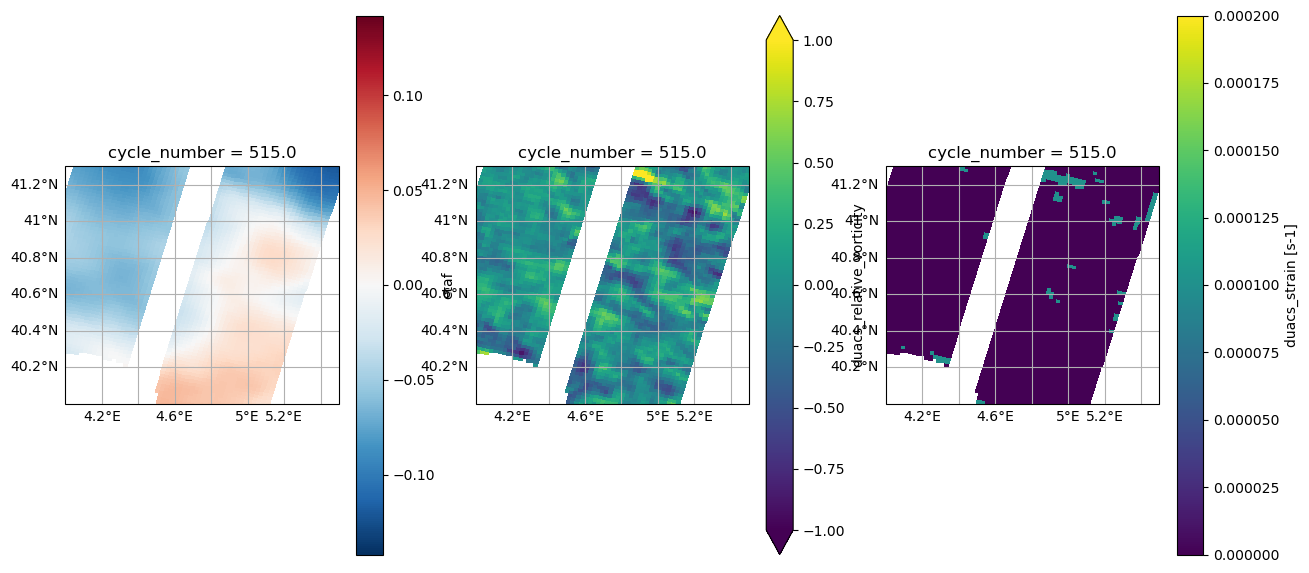

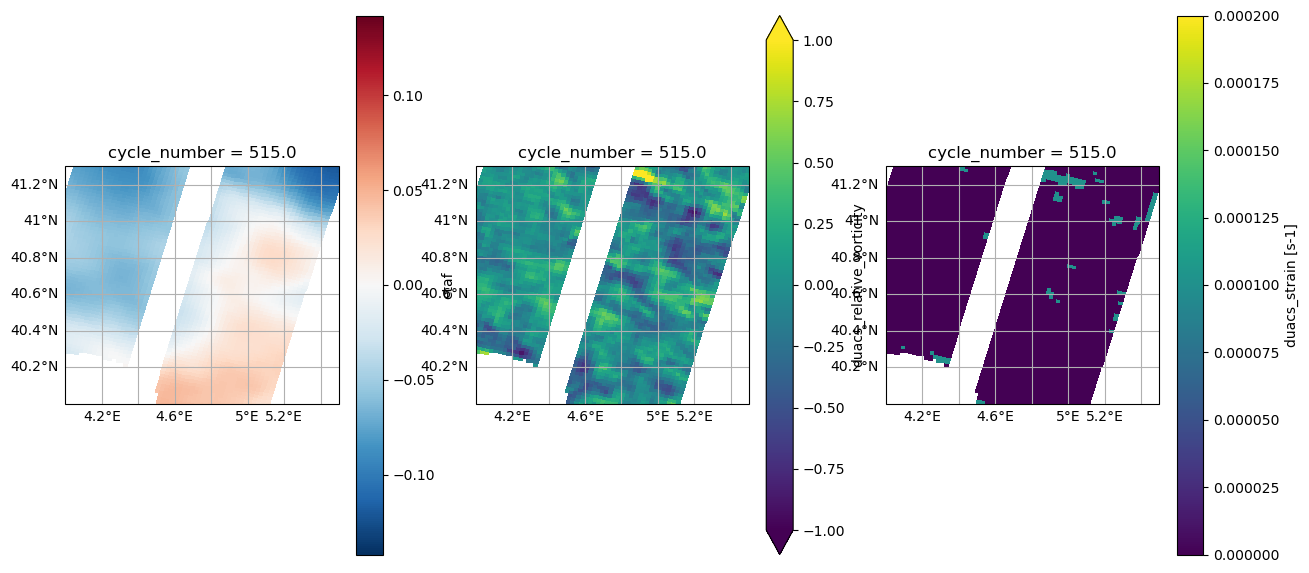

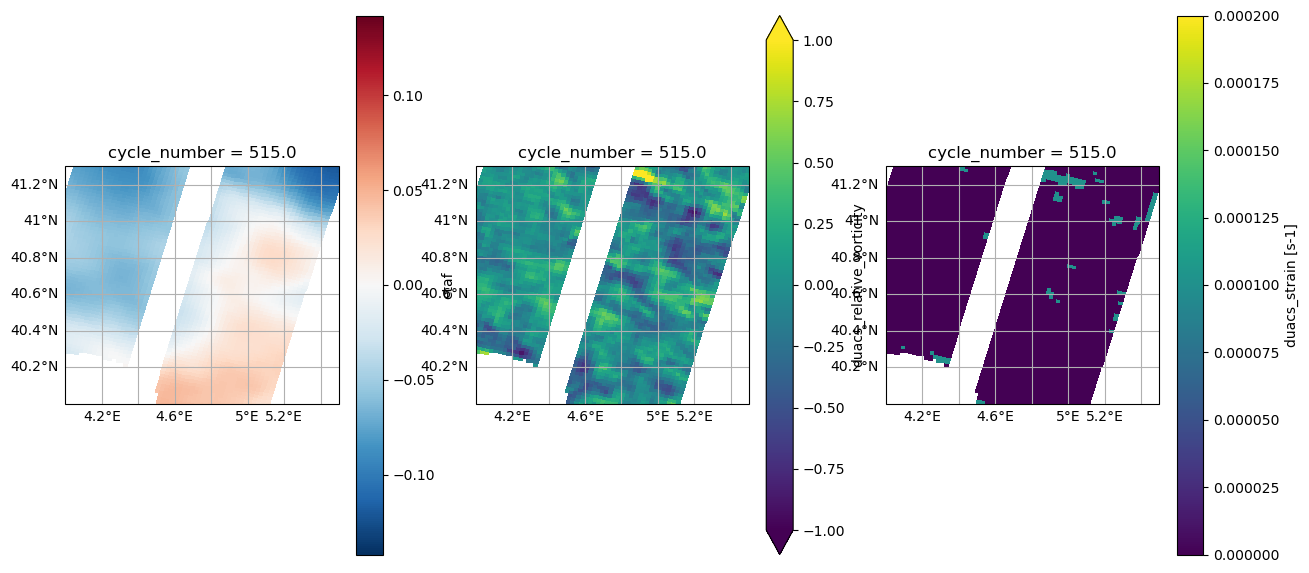

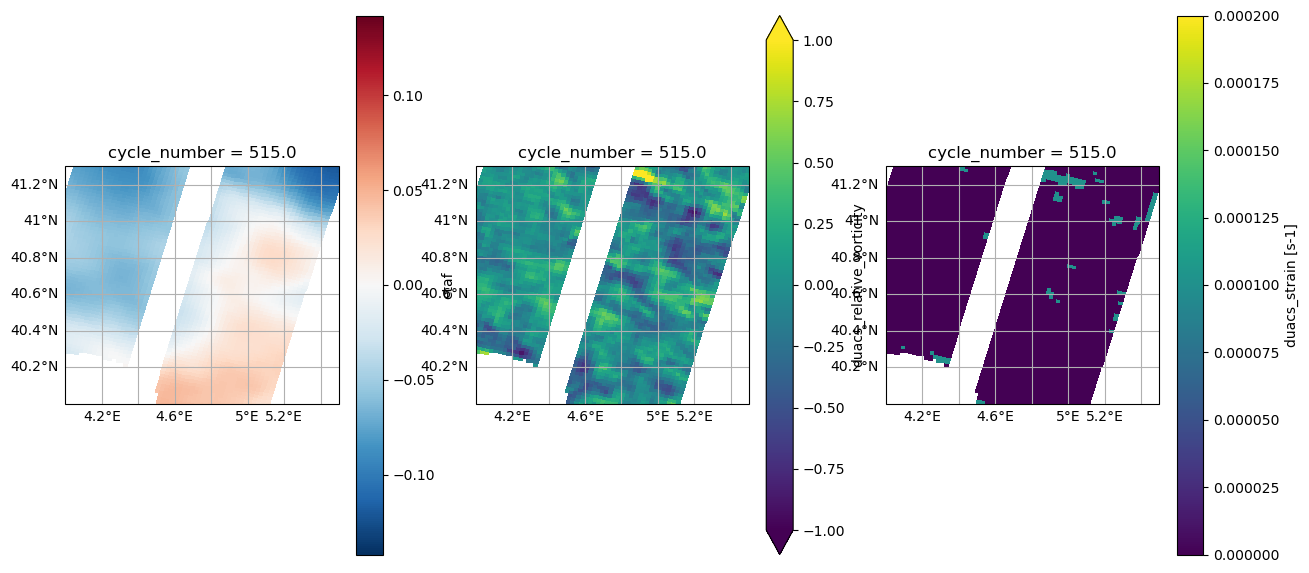

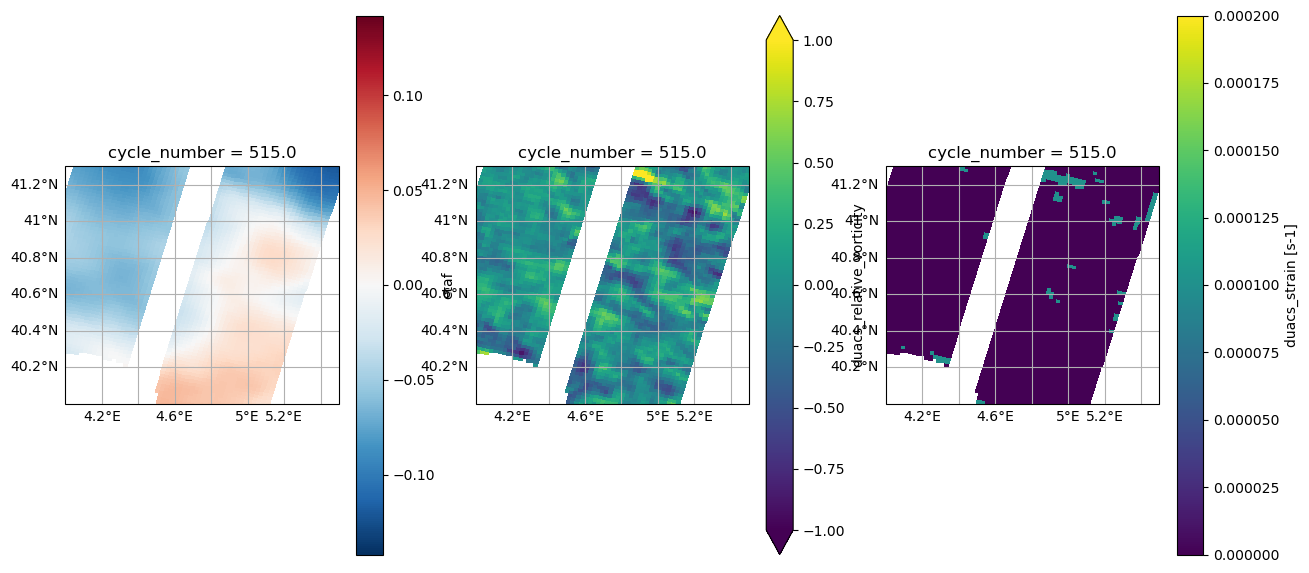

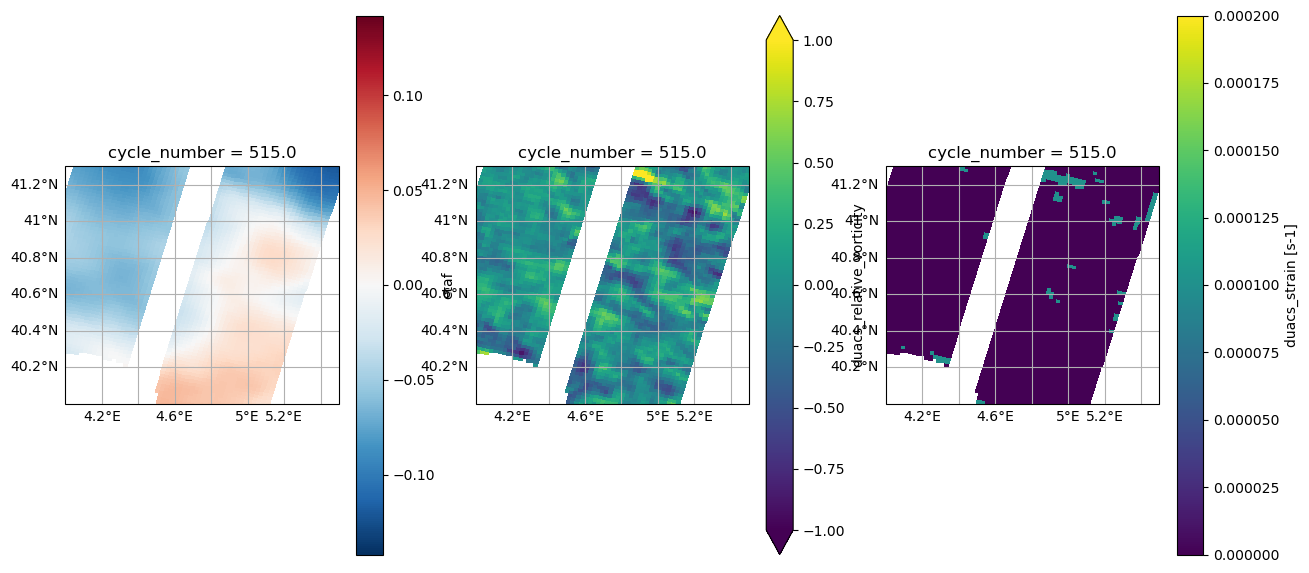

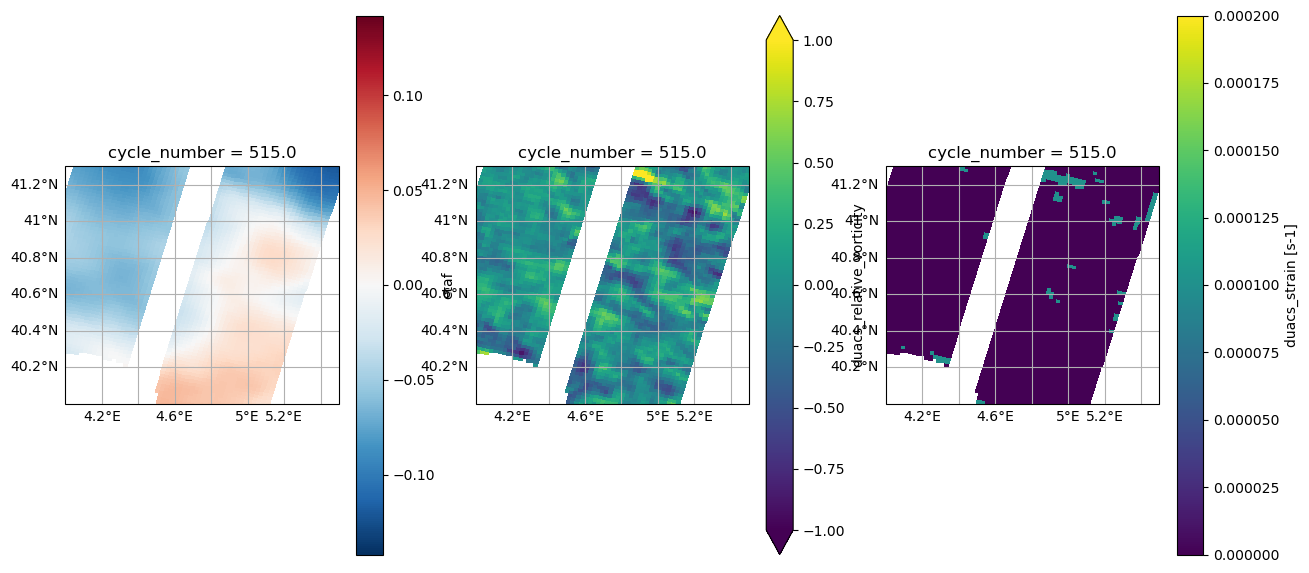

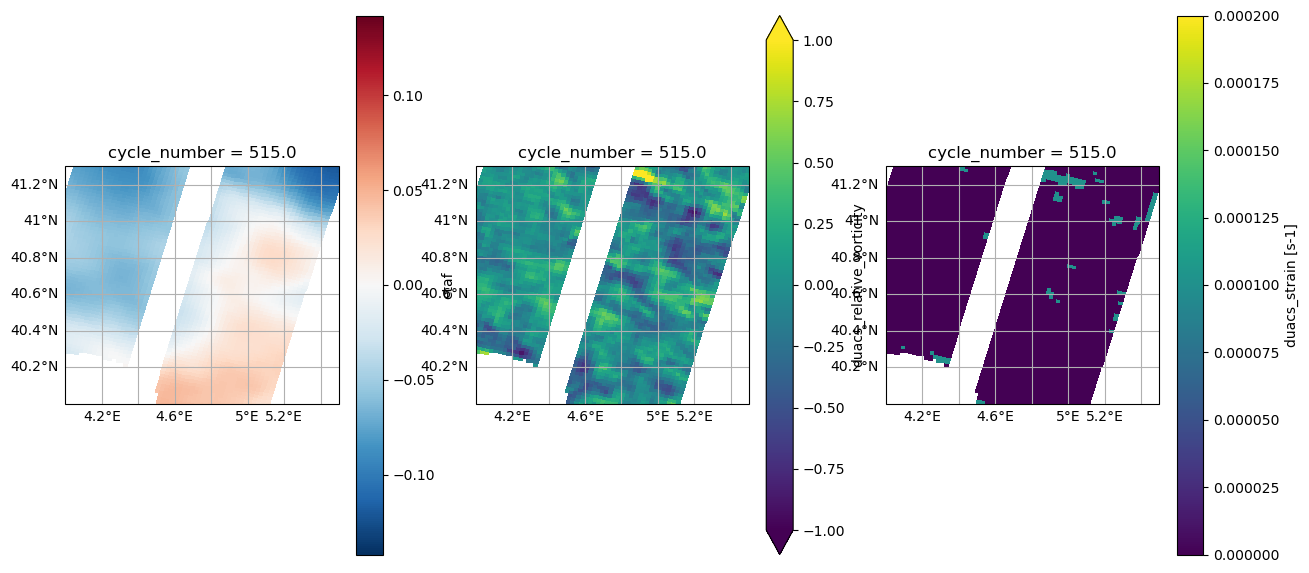

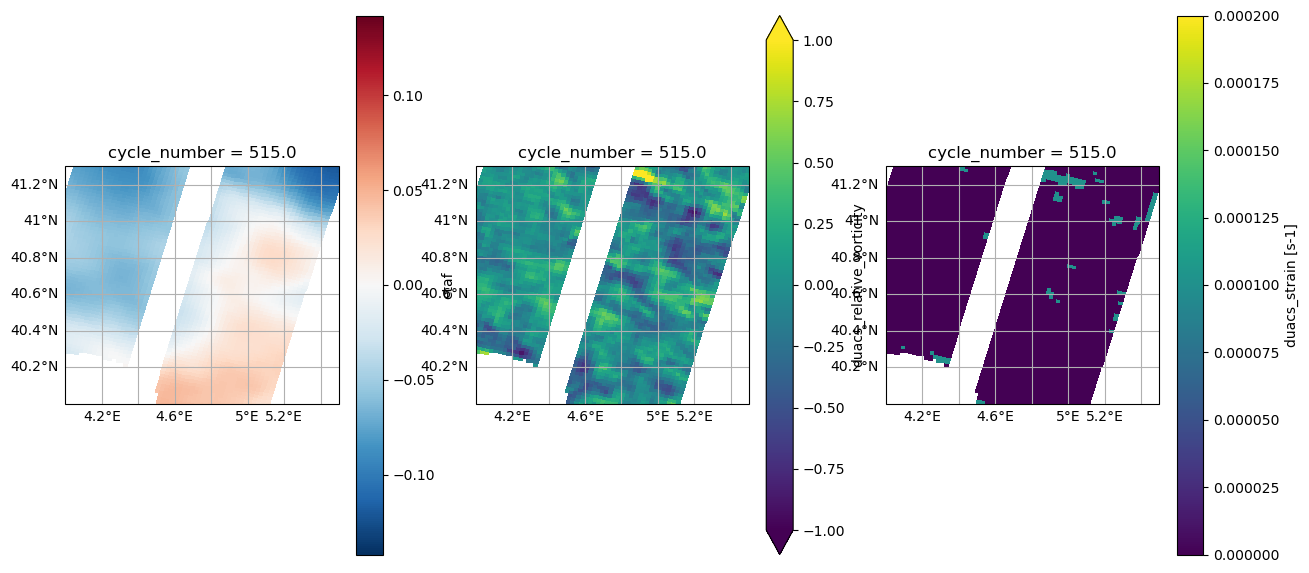

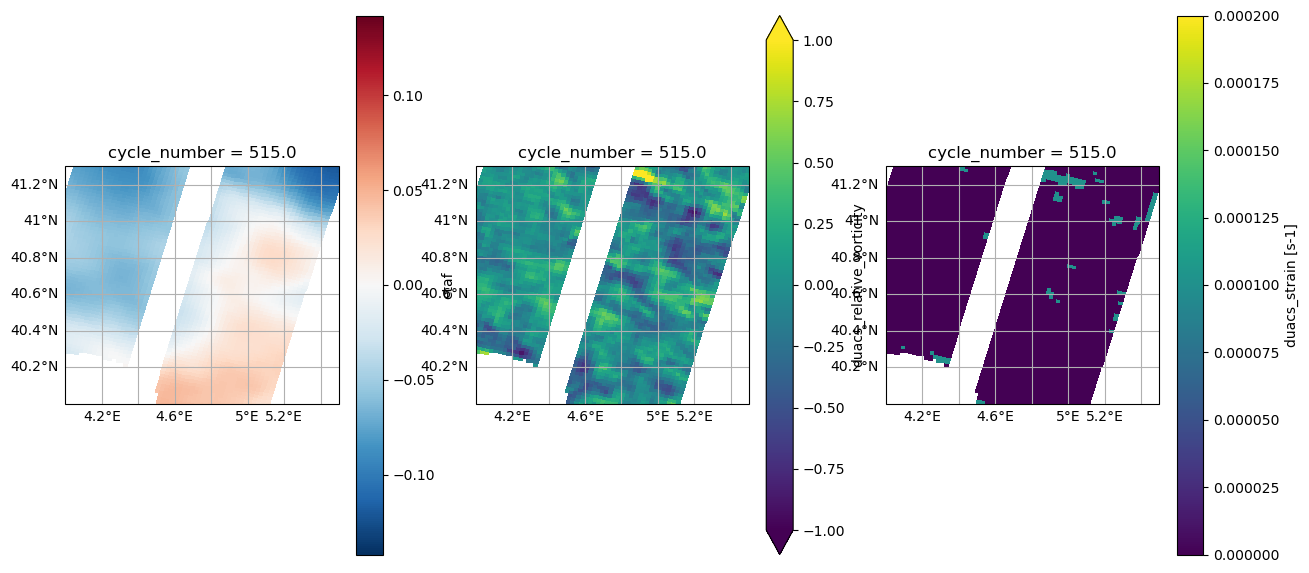

In [5]:
for i in range(510, 525, 1):
    bbox = [4, 5.5, 40, 41.3]
    
    fig, axs = plt.subplots(1, 3, figsize=(15,7), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()), sharey=True)

    ax=axs[0]
    kw = dict(transform=crs)
    dss3_.etaf.sel(cycle_number=i, method='nearest').plot(x='longitude', y='latitude',ax=ax, **kw)

    ax=axs[1]
    kw = dict(transform=crs, vmin = -1, vmax = 1)
    dss3_.duacs_relative_vorticity.sel(cycle_number=i, method='nearest').plot(x='longitude', y='latitude',ax=ax, **kw)
    
    ax=axs[2]
    #kw = dict(vmin = 0, vmax = 1e-4)
    dss3_.duacs_strain.sel(cycle_number=i, method='nearest').plot(x='longitude', y='latitude', ax=ax)#, **kw)
    
    for ax in axs :
        ax.set_extent(bbox)
        gl = ax.gridlines(draw_labels=True,)
        gl.xlabels_top = False
        gl.ylabels_right = False

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


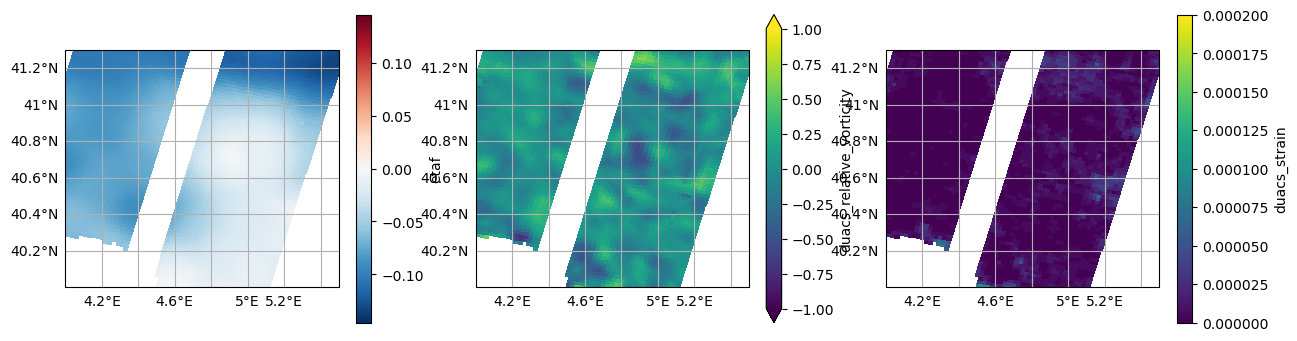

In [6]:

bbox = [4, 5.5, 40, 41.3]

fig, axs = plt.subplots(1, 3, figsize=(15,4), frameon=False, subplot_kw=dict(projection=ccrs.PlateCarree()), sharey=True)

ax=axs[0]
kw = dict(transform=crs)
dss3_.etaf.mean('cycle_number').plot(x='longitude', y='latitude',ax=ax, **kw)

ax=axs[1]
kw = dict(transform=crs, vmin = -1, vmax = 1)
dss3_.duacs_relative_vorticity.mean('cycle_number').plot(x='longitude', y='latitude',ax=ax, **kw)

ax=axs[2]
#kw = dict(vmin = 0, vmax = 1e-4)
dss3_.duacs_strain.mean('cycle_number').plot(x='longitude', y='latitude', ax=ax)#, **kw)

for ax in axs :
    ax.set_extent(bbox)
    gl = ax.gridlines(draw_labels=True,)
    gl.xlabels_top = False
    gl.ylabels_right = False

_______
# Data

In [7]:
DT = 12
distance_to_coast_max = 20e3

In [8]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = 'spectral_decomp',
        drifter_preprocess_param='LF',
        alti_product_key='swot2km',
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list = [base_dic]


ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0 = ds0.where(ds0.depth==0, drop=True)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)
ds0 = ds0.where(ds0.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
#ds0 = ds0.where((abs(ds0.ggde)<1e-4) & (abs(ds0.ggdn)<1e-4), drop=True)
ds0 = ds0.where(ds0.distance_to_coast>distance_to_coast_max, drop=True)

df0 = ds0.to_dataframe().reset_index().set_index('row_number')

#DEPTH 15M
base_dic = dict(dt='12h', 
            drifter_preprocess = 'spectral_decomp',
            drifter_preprocess_param='LF',
            alti_product_key='swot2km',
            alti_diff_method = 'fromduacsv',
            alti_diff_method_param = '',
            ggd_var = 'fromduacsv',
            wd_product_key = 'era5', 
            wd_model ='rio', 
            wd_depth = '15')

comb_list = [    
    base_dic, 
]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15 =ds15.where(ds15.depth==15, drop=True)
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)
ds15 = ds15.where(ds15.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
#ds15 = ds15.where((abs(ds15.ggde)<1e-4) & (abs(ds15.ggdn)<1e-4), drop=True)
ds15 = ds15.where(ds15.distance_to_coast>distance_to_coast_max, drop=True)

df15 = ds15.to_dataframe().reset_index().set_index('row_number')

12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed


In [9]:
dfs = prepared_alti(dt='12h', 
        drifter_preprocess = '',
        drifter_preprocess_param='',
        alti_product_key='swot2km',
        alti_diff_method = 'xarray_diff' ,
        alti_diff_method_param = '')

In [10]:
def concat(df, dfs, from_='mano'):
    df = pd.concat([df, dfs[['vorticity_etaf', 'strain_s_etaf', 'strain_n_etaf',]]], axis=1).dropna()
    df['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(df.latitude * np.pi / 180)
    fo = df.f.mean()
    # From computation
    if from_ =='mano' :
        df['strain_f'] = np.sqrt(df.strain_n_etaf**2 + df.strain_s_etaf**2)
        df['strain'] = df.strain_f*df.f#.assign_attrs({'long_name':r'$\sigma/|f|$'})
        df['vorticity'] = df.vorticity_etaf*df.f#.assign_attrs({'long_name':r'$\zeta/f$'})
        df['vorticity_f'] = df.vorticity_etaf#.assign_attrs({'long_name':r'$\zeta/f$'})
        df['omega'] = df.strain**2 - df.vorticity**2
    # From duacs
    elif from_ =='duacs' :
        df['strain_f'] = dfs.duacs_strain/df.f
        df['strain'] = df.strain_f*df.f
        df['vorticity_f'] = dfs.duacs_relative_vorticity
        df['vorticity'] = df.vorticity_f*df.f
        df['omega'] = df.strain**2 - df.vorticity**2
    return df
df0 = concat(df0, dfs)
df15 = concat(df15, dfs)

In [11]:
df15

,id_comb,sume,acce,exce_acc,core,exce_cor,ggde,exce_ggd,wde,exce_wd,...,distance_to_coast,vorticity_etaf,strain_s_etaf,strain_n_etaf,f,strain_f,strain,vorticity,vorticity_f,omega
row_number,,,,,,,,,,,,,,,,,,,,,
1826,12h_spectral_decomp_all_med_variational_10min_...,-0.000009,3.528261e-06,-0.000013,-0.000008,-1.127354e-06,4.277679e-06,-0.000013,-8.933295e-06,-6.198938e-08,...,118660.508720,-0.196084,0.142589,-0.0,0.000098,0.142589,0.000014,-0.000019,-0.196084,-1.740148e-10
1827,12h_spectral_decomp_all_med_variational_10min_...,-0.000009,3.520546e-06,-0.000012,-0.000008,-1.130328e-06,4.294258e-06,-0.000013,-8.945132e-06,5.786780e-08,...,118507.122386,-0.210012,0.152585,-0.0,0.000098,0.152585,0.000015,-0.000021,-0.210012,-2.000088e-10
1828,12h_spectral_decomp_all_med_variational_10min_...,-0.000009,3.510765e-06,-0.000012,-0.000008,-1.216663e-06,4.232981e-06,-0.000013,-8.960408e-06,1.012300e-07,...,118455.531932,-0.213999,0.155523,-0.0,0.000098,0.155523,0.000015,-0.000021,-0.213999,-2.075524e-10
1829,12h_spectral_decomp_all_med_variational_10min_...,-0.000009,3.498953e-06,-0.000012,-0.000008,-1.314978e-06,4.165257e-06,-0.000013,-8.979189e-06,1.394738e-07,...,118401.326572,-0.218087,0.158708,-0.0,0.000098,0.158708,0.000016,-0.000021,-0.218087,-2.149088e-10
1830,12h_spectral_decomp_all_med_variational_10min_...,-0.000009,3.485151e-06,-0.000012,-0.000007,-1.425001e-06,4.091383e-06,-0.000013,-9.001534e-06,1.728622e-07,...,118344.774155,-0.222260,0.162110,-0.0,0.000098,0.162110,0.000016,-0.000022,-0.222260,-2.220795e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377354,12h_spectral_decomp_all_med_variational_10min_...,0.000002,2.892436e-07,0.000002,0.000002,6.731152e-08,-2.923209e-07,0.000002,7.038883e-08,1.752600e-06,...,30413.830903,0.265523,-0.095569,-0.0,0.000092,0.095569,0.000009,0.000025,0.265523,-5.239245e-10
377355,12h_spectral_decomp_all_med_variational_10min_...,0.000002,3.000500e-07,0.000002,0.000002,1.975072e-07,-1.714699e-07,0.000002,6.892712e-08,1.875387e-06,...,30165.578597,0.256294,-0.088799,-0.0,0.000092,0.088799,0.000008,0.000024,0.256294,-4.934581e-10
377356,12h_spectral_decomp_all_med_variational_10min_...,0.000002,3.108530e-07,0.000002,0.000002,2.558044e-07,-1.225558e-07,0.000002,6.750723e-08,1.926276e-06,...,30123.393122,0.253113,-0.086141,-0.0,0.000092,0.086141,0.000008,0.000023,0.253113,-4.835815e-10


_______
# Visualized

<Axes: ylabel='Frequency'>

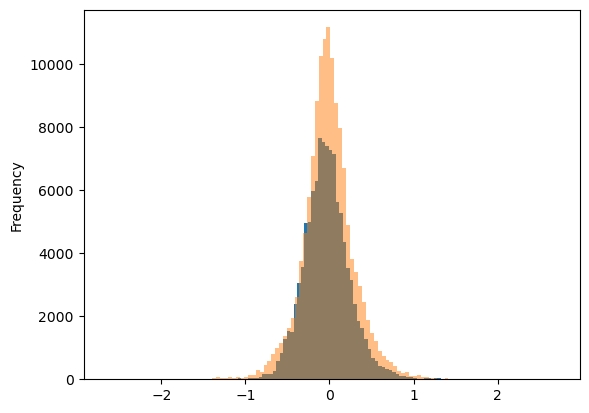

In [12]:
(df15.vorticity/df15.f).plot.hist(bins=100, label= 'naive vorticity')
(df0.vorticity/df0.f).plot.hist(bins=100, label= 'naive vorticity', alpha = 0.5)
#df.duacs_vorticity_f.plot.hist(bins=100, label= 'duacs vorticity', alpha=0.5)
#plt.legend()

In [13]:
def plot_join_pdfs(ds, x, y, binx=100, biny=100):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x],coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    plt.rcParams["axes.edgecolor"] = "k"
    fig = plt.figure(figsize=(9, 4))
    
    # Add a gridspec with two rows and two columns and a ratio of 2 to 7 between
    # the size of the marginal axes and the main axes in both directions.
    # Also adjust the subplot parameters for a square plot.
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(7, 2),
        height_ratios=(2, 7),
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.05,
        hspace=0.05,
    )
    
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
    

    from matplotlib import colors
    da.plot.pcolormesh(ax=ax, norm=colors.LogNorm(), vmin=1e0, add_colorbar=False,)
    da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    ax.plot(xx, xx, color='r')
    #ax.plot(xx, 3/4 * xx, color='orange')
    ax.plot(xx, -xx, color='r')
    ds[x].plot.hist(bins=binx, density=True, ax=ax_histx, zorder=1)
    ds[y].plot.hist(
        bins=biny,
        density=True,
        ax=ax_histy,
        orientation="horizontal",
        zorder=1,
    )


    # no labels
    ax.grid(zorder=0)
    ax_histx.grid()
    ax_histy.grid()
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_title('')
    ax_histx.set_title('')
    ax_histy.set_xlabel('')
    ax_histx.set_xlabel('')
    return fig, ax, ax_histx, ax_histy
    #fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

def plot_join_pdfs_one(ds, x, y, binx=100, biny=100, ax=None):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x], coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    plt.rcParams["axes.edgecolor"] = "k"
    
    from matplotlib import colors
    da.where(da!=0).plot.pcolormesh(ax=ax, norm=colors.LogNorm(), vmin=1e0)
    da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    ax.plot(xx, xx, color='r')
    #ax.plot(xx, 3/4 * xx, color='orange')
    ax.plot(xx, -xx, color='r')
    ax.grid()
    


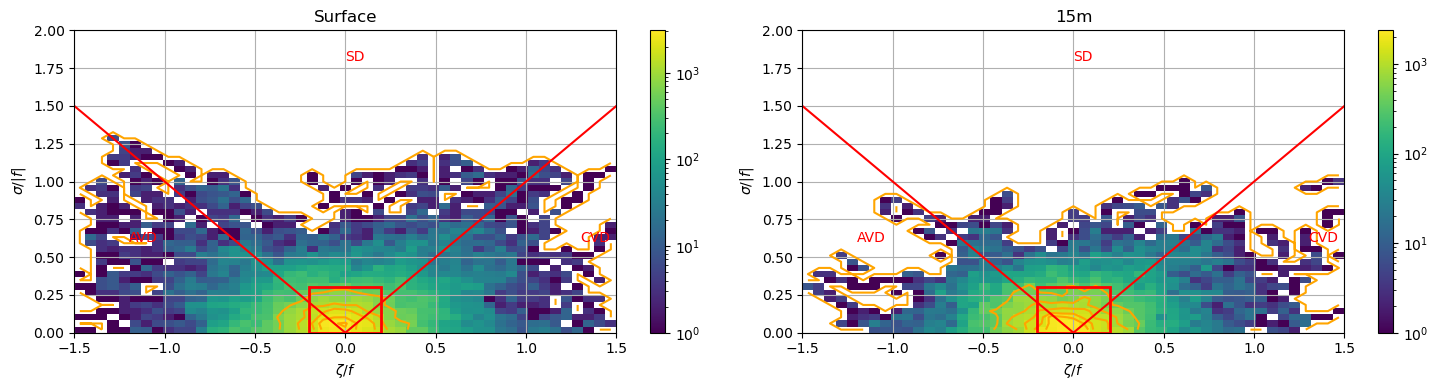

In [14]:
fig, axs = plt.subplots(1, 2, figsize =(15, 4), frameon=False)

ax=axs[0]
plot_join_pdfs_one(df0, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 2,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')

import matplotlib.patches as patches
# Create a Rectangle patch
rect = patches.Rectangle((-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor='r', facecolor='none', zorder = 10)
# Add the patch to the Axes
ax.add_patch(rect)

ax.annotate('AVD', (-1.2, 0.6), c='r')
ax.annotate('SD', (0, 1.8), c='r')
ax.annotate('CVD', (1.3, 0.6), c='r')

ax.set_title('Surface')


ax=axs[1]
plot_join_pdfs_one(df15, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 2,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')

import matplotlib.patches as patches
# Create a Rectangle patch
rect = patches.Rectangle((-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor='r', facecolor='none', zorder = 10)
# Add the patch to the Axes
ax.add_patch(rect)

ax.annotate('AVD', (-1.2, 0.6), c='r')
ax.annotate('SD', (0, 1.8), c='r')
ax.annotate('CVD', (1.3, 0.6), c='r')

ax.set_title('15m')

fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'all', f'15m_diagvortstrain_DT{DT}.png'))

/dev/shm/pbs.3586268.datarmor0/ipykernel_49467/1684253255.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df0_ = df0_[~((df0.vorticity_f<=df0.strain_f+0.15)&(df0.vorticity_f>=df0.strain_f-0.15))]
/dev/shm/pbs.3586268.datarmor0/ipykernel_49467/1684253255.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df0_ = df0_[~((df0.vorticity_f<=-df0.strain_f+0.15)&(df0.vorticity_f>=-df0.strain_f-0.15))]
/dev/shm/pbs.3586268.datarmor0/ipykernel_49467/1684253255.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df15_ = df15_[~((df15.vorticity_f<=df15.strain_f+0.15)&(df15.vorticity_f>=df15.strain_f-0.15))]
/dev/shm/pbs.3586268.datarmor0/ipykernel_49467/1684253255.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df15_ = df15_[~((df15.vorticity_f<=-df15.strain_f+0.15)&(df15.vorticity_f>=-df15.strain_f-0.15))]


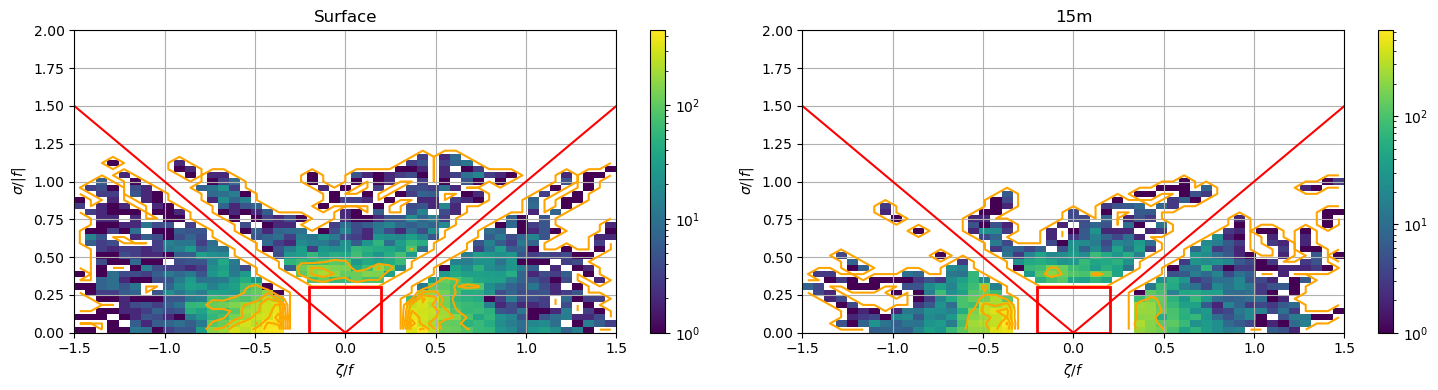

In [15]:
df0_ = df0[~((abs(df0.vorticity_f)<=0.35)&(df0.strain_f<=0.35))]
df0_ = df0_[~((df0.vorticity_f<=df0.strain_f+0.15)&(df0.vorticity_f>=df0.strain_f-0.15))]
df0_ = df0_[~((df0.vorticity_f<=-df0.strain_f+0.15)&(df0.vorticity_f>=-df0.strain_f-0.15))]
df15_ = df15[~((abs(df15.vorticity_f)<=0.35)&(df15.strain_f<=0.35))]
df15_ = df15_[~((df15.vorticity_f<=df15.strain_f+0.15)&(df15.vorticity_f>=df15.strain_f-0.15))]
df15_ = df15_[~((df15.vorticity_f<=-df15.strain_f+0.15)&(df15.vorticity_f>=-df15.strain_f-0.15))]


plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(1, 2, figsize =(15, 4), frameon=False)

ax = axs[0]
plot_join_pdfs_one(df0_, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 2,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')
import matplotlib.patches as patches
# Create a Rectangle patch
rect = patches.Rectangle((-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor='r', facecolor='none', zorder = 10)
# Add the patch to the Axes
ax.add_patch(rect)
ax.set_title('Surface')


ax = axs[1]
plot_join_pdfs_one(df15_, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 2,50), ax=ax)
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')
import matplotlib.patches as patches
# Create a Rectangle patch
rect = patches.Rectangle((-0.2, 0), 0.4, 0.3, linewidth=2, edgecolor='r', facecolor='none', zorder = 10)
# Add the patch to the Axes
ax.add_patch(rect)
ax.set_title('15m')


fig.tight_layout()


____
# Closure

In [16]:
DSz0 = {'AVD': df0_[(df0_.vorticity<0) & (df0_.strain<abs(df0_.vorticity))].to_xarray(), 
       'CVD': df0_[(df0_.vorticity>0) & (df0_.strain<abs(df0_.vorticity))].to_xarray(), 
       'SD': df0_[df0_.strain>=abs(df0_.vorticity)].to_xarray()}

DSz15 = {'AVD': df15_[(df15_.vorticity<0) & (df15_.strain<abs(df15_.vorticity))].to_xarray(), 
       'CVD': df15_[(df15_.vorticity>0) & (df15_.strain<abs(df15_.vorticity))].to_xarray(), 
       'SD': df15_[df15_.strain>=abs(df15_.vorticity)].to_xarray()}

ds0 = xr.concat([DSz0[k].rename({'id_comb':'comb'}) for k in DSz0], dim=pd.Index(DSz0.keys(), name='id_comb'))
ds15 = xr.concat([DSz15[k].rename({'id_comb':'comb'}) for k in DSz15], dim=pd.Index(DSz15.keys(), name='id_comb'))

df0m = compute_variance(ds0, compute_error = 'centrallimit').to_dataframe()/U2
df15m = compute_variance(ds15, compute_error = 'centrallimit').to_dataframe()/U2

331
239


/dev/shm/pbs.3586268.datarmor0/ipykernel_49467/4088666935.py:49: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axs[0].annotate('AVD',xy = (-0.23, 0.5),  xycoords='axes fraction', textcoords='offset points',size='large', ha='center', va='center', rotation = 90)
/dev/shm/pbs.3586268.datarmor0/ipykernel_49467/4088666935.py:50: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axs[2].annotate('SD',xy = (-0.23, 0.5),  xycoords='axes fraction', textcoords='offset points',size='large', ha='center', va='center', rotation = 90)
/dev/shm/pbs.3586268.datarmor0/ipykernel_49467/4088666935.py:51: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axs[4].annotate('CVD',xy = (-0.23, 0.5),  xycoords='axes fraction', textcoords='offset points',size='large', ha='center', va='center', rotation = 90)

Text(-0.23, 0.5, 'CVD')

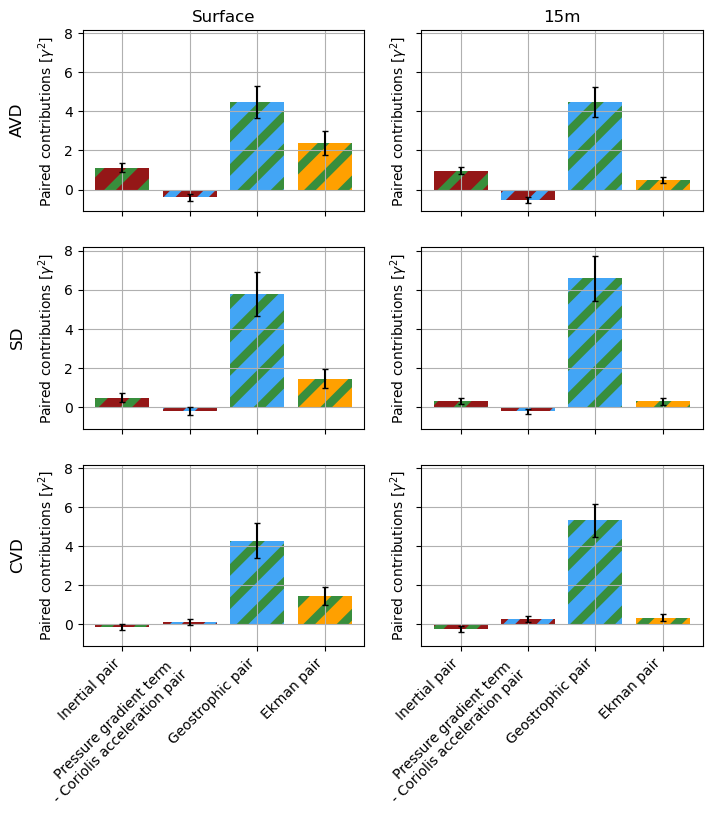

In [23]:
plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6
fig, axs = plt.subplots(3, 2, figsize = (8,8), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()

kwargs = dict(hatch="/",width = 0.8, capsize=2)

def plot_one_axis(df, domain, ax):
    plt.rcParams["hatch.color"] = c0['cor']
    df_ = df.loc[domain]
    
    plt.rcParams["hatch.color"] = c0['cor']
    ax.bar(0, df_.X_acc_cor, color = c0['acc'], yerr =df_['er__X_acc_cor'], **kwargs)

    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(1, df_.X_acc_ggd, color = c0['acc'],  yerr =df_['er__X_acc_ggd'], **kwargs)

    plt.rcParams["hatch.color"] = c0['cor']
    ax.bar(2, df_.X_cor_ggd, color = c0['ggd'], yerr =df_['er__X_cor_ggd'], **kwargs)

    plt.rcParams["hatch.color"] = c0['cor']
    ax.bar(3, df_.X_cor_wd, color = c0['wd'], yerr =df_['er__X_cor_wd'], **kwargs)
    
    #plt.rcParams["hatch.color"] = c0['acc']
    #ax.bar(4, df_.X_acc_wd, color = c0['wd'], yerr =df_['er__X_acc_wd'], **kwargs)
        
    #plt.rcParams["hatch.color"] = c0['ggd']
    #ax.bar(5, df_.X_ggd_wd, color = c0['wd'], yerr =df_['er__X_ggd_wd'], **kwargs)
    
    ax.grid()
    ax.set_ylabel(rf'Paired contributions [$\gamma^2$]')
    #ax.set_xticks([0, 1, 2, 3], ['Inertial balance', 'Pressure gradient term \n - Coriolis acceleration', 'Geostrophic balance', 'Ekman balance'], rotation=45, ha='right')
    ax.set_xticks([0, 1, 2, 3], ['Inertial pair', 'Pressure gradient term \n - Coriolis acceleration pair', 'Geostrophic pair', 'Ekman pair'], rotation=45, ha='right')



    
plot_one_axis(df0m, 'AVD', axs[0]) 
plot_one_axis(df0m, 'SD', axs[2]) 
plot_one_axis(df0m, 'CVD', axs[4]) 
plot_one_axis(df15m, 'AVD', axs[1]) 
plot_one_axis(df15m, 'SD', axs[3]) 
plot_one_axis(df15m, 'CVD', axs[5]) 

axs[0].set_title('Surface')
axs[1].set_title('15m')

pad=0
axs[0].annotate('AVD',xy = (-0.23, 0.5),  xycoords='axes fraction', textcoords='offset points',size='large', ha='center', va='center', rotation = 90)
axs[2].annotate('SD',xy = (-0.23, 0.5),  xycoords='axes fraction', textcoords='offset points',size='large', ha='center', va='center', rotation = 90)
axs[4].annotate('CVD',xy = (-0.23, 0.5),  xycoords='axes fraction', textcoords='offset points',size='large', ha='center', va='center', rotation = 90)

/dev/shm/pbs.3586268.datarmor0/ipykernel_49467/3857551764.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz15[k].dims['row_number'])
/dev/shm/pbs.3586268.datarmor0/ipykernel_49467/3857551764.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz15[k].dims['row_number'])


9976
6373


/dev/shm/pbs.3586268.datarmor0/ipykernel_49467/3857551764.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz15[k].dims['row_number'])


3891
7.249341027595219
7.83377718858049
8.225980542248616
8.45224026307043
9.082120253761543
9.29537029753265


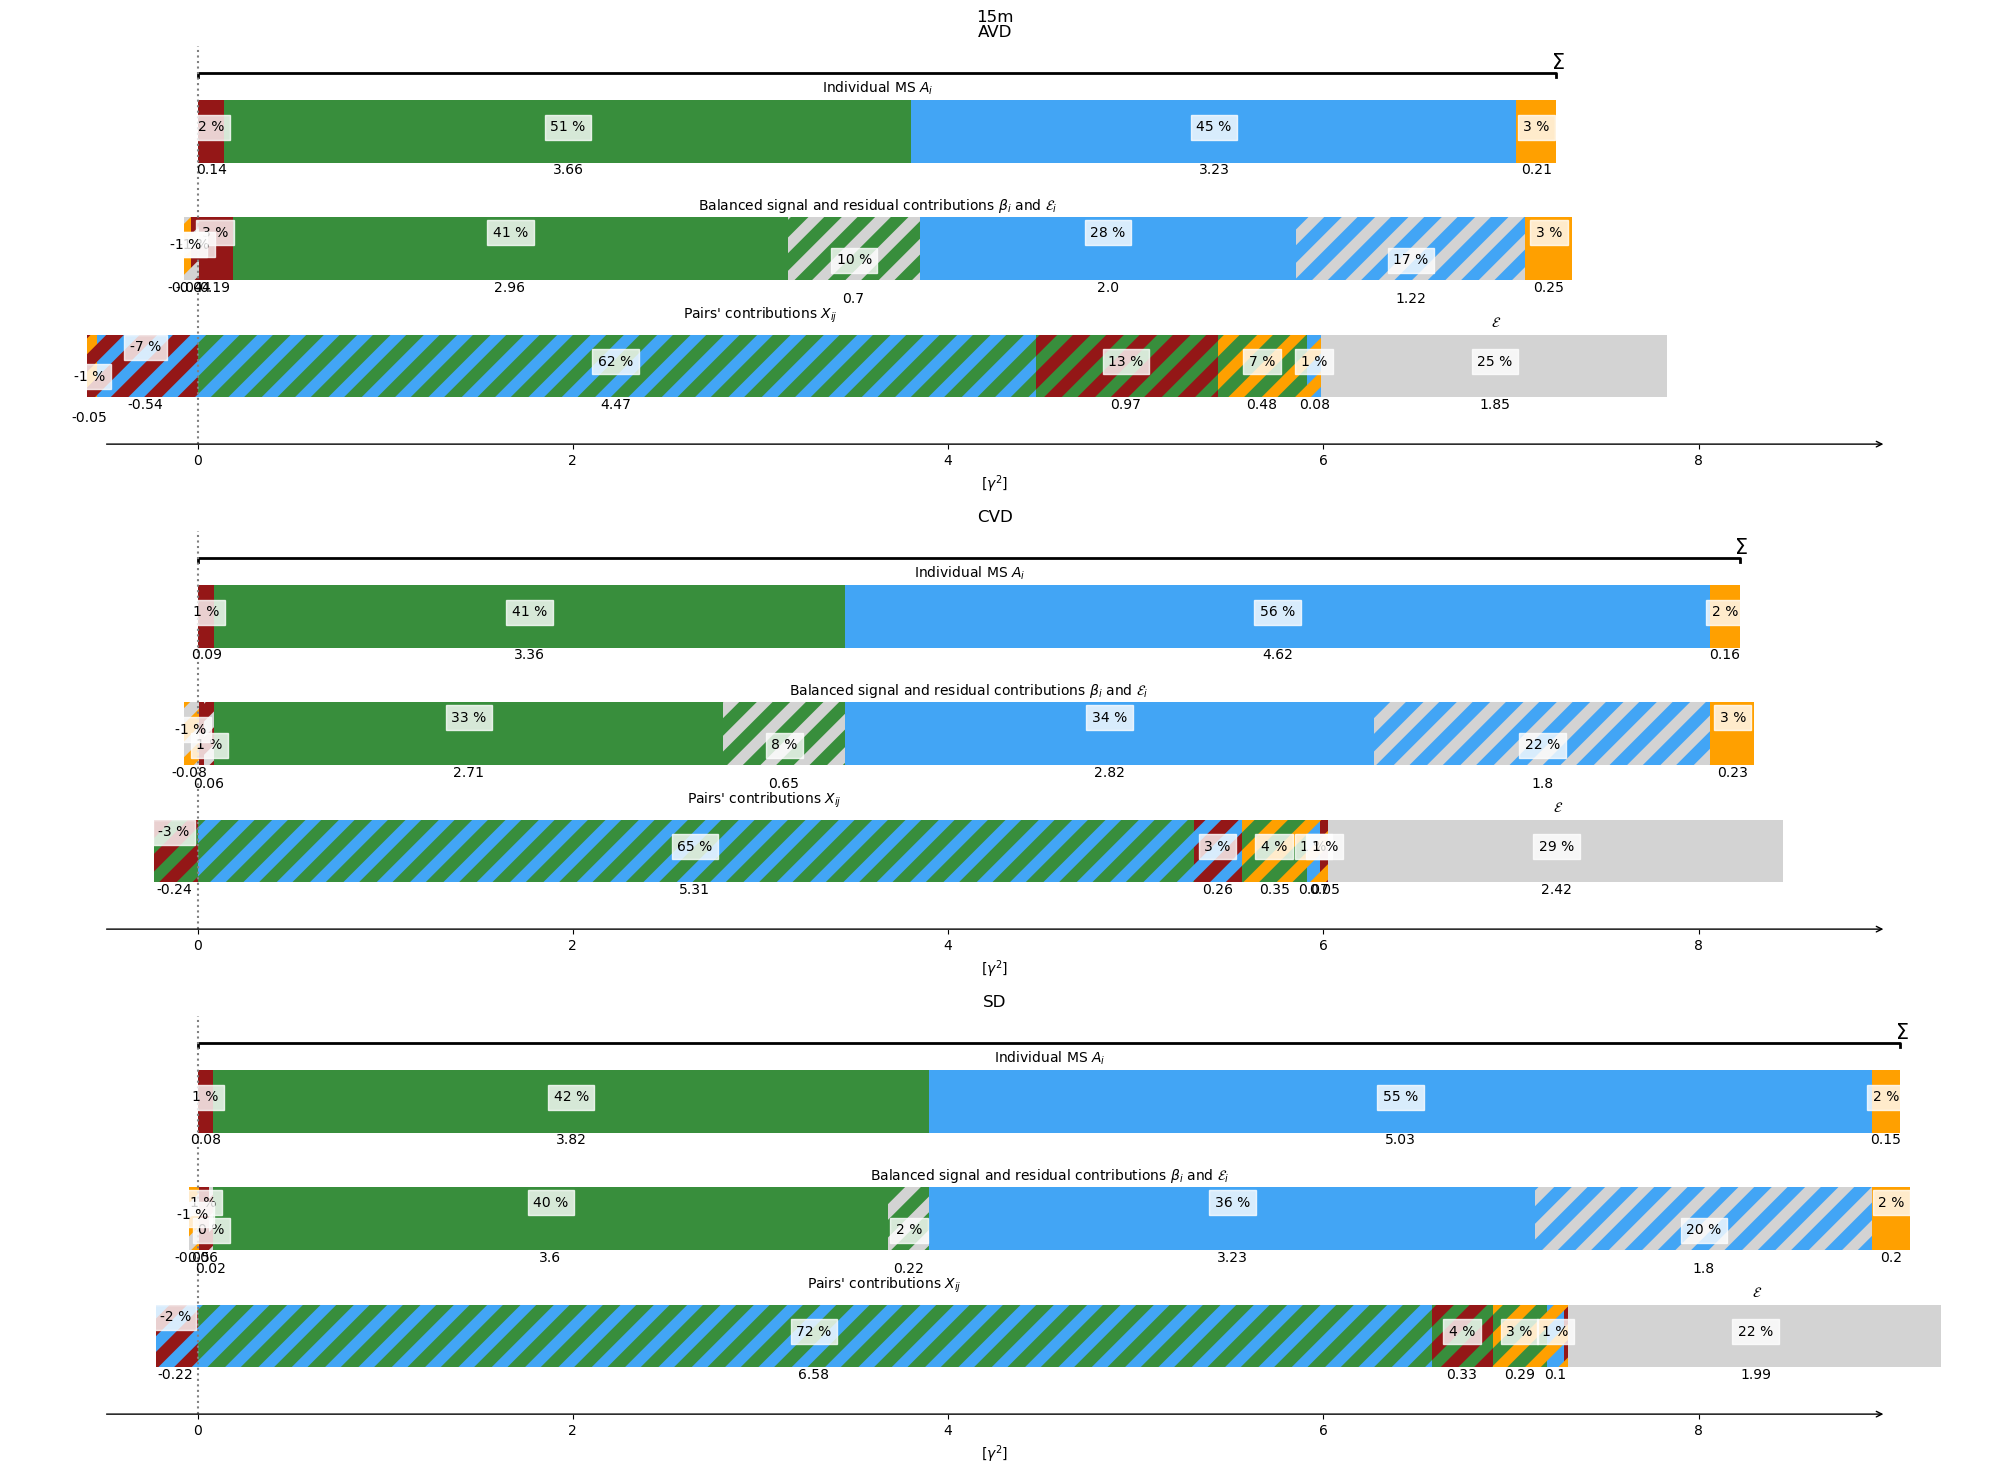

In [20]:
D = []
# Closure figs
for k in DSz15:
    print(DSz15[k].dims['row_number'])
    D.append(compute_variance(DSz15[k])/U2)
dsz = xr.concat(D, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))
dfz =dsz.to_dataframe()

plt.rcParams["axes.edgecolor"] = "w"
fig, axs = plt.subplots(nrows=3,ncols=1,figsize=(20,15), frameon=False)
i = 0
for d in dfz.index :
    synthetic_figure(dfz.loc[d], axs[i], dir='', xlim=[-1, 9])
    axs[i].set_title(d)
    i+=1
fig.suptitle('15m')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'all', '15m_closure_avdcvdsd.png'))

In [21]:
DSz0['AVD'].drop_vars('time_to_swot').mean()/DSz0['AVD'].drop_vars('time_to_swot').std()

<xarray.Dataset> Size: 368B
Dimensions:            ()
Data variables: (12/46)
    sume               float64 8B 0.06872
    acce               float64 8B -0.02245
    exce_acc           float64 8B 0.07172
    core               float64 8B 0.4564
    exce_cor           float64 8B -0.3457
    ggde               float64 8B -0.1366
    ...                 ...
    f                  float64 8B 55.81
    strain_f           float64 8B 1.076
    strain             float64 8B 1.083
    vorticity          float64 8B -2.609
    vorticity_f        float64 8B -2.61
    omega              float64 8B -0.8986

In [ ]:
D = []
# Closure figs
for k in DSz0:
    print(DSz0[k].dims['row_number'])
    D.append(compute_variance(DSz0[k])/U2)
dsz = xr.concat(D, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))
dfz =dsz.to_dataframe()


plt.rcParams["axes.edgecolor"] = "w"
fig, axs = plt.subplots(nrows=3,ncols=1,figsize=(20,15), frameon=False)
i = 0
for d in dfz.index :
    synthetic_figure(dfz.loc[d], axs[i], dir='', xlim=[-2, 12])
    axs[i].set_title(d)
    i+=1
fig.suptitle('Surface')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'all', '15m_closure_avdcvdsd.png'))

_________
# Where ?

In [ ]:
Dll = []
dl=0.05
lonbins = np.arange(0.9, 6.1, dl)
latbins = np.arange(37.9, 43.4, dl)
for k in DSz:
    dfl = DSz[k].to_dataframe()
    dfl['longitude_cut']= pd.cut(dfl['longitude'], lonbins, labels=(lonbins[1:] + lonbins[:-1])/2)
    dfl['latitude_cut']= pd.cut(dfl['latitude'], latbins, labels=(latbins[1:] + latbins[:-1])/2)
    Dll.append(compute_variance_groupby(dfl, groupby = ['latitude_cut', 'longitude_cut'], dirname = ('e', 'n'),  vars_errors=None))

dll = xr.concat(Dll, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))

plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(1,3, sharey=True, frameon = False, figsize = (15, 5), subplot_kw={'projection':ccrs.Orthographic(1.6,39.5)})
i=0
for d in dll.dyn.values:
    ax=axs[i]
    dll.sel(dyn=d).where(dll.sel(dyn=d).nb_coloc!=0).nb_coloc.assign_attrs(long_name='Number of coloc per 0.02° bins').plot(ax=ax, transform=crs)
    ax.set_title(d)
    i+=1

for ax in axs : 
    gl = ax.gridlines(draw_labels=True,)
    gl.top_labels=False   # suppress top labels
    gl.right_labels=False
    #ax.add_feature(cfeature.LAND,)

fig.tight_layout()


____
# BIOSWOT-SWOT anticyclonic eddy

In [ ]:
dfa = df0[(df0.latitude>40)&(df0.latitude<41.3)&(df0.longitude>4.5)&(df0.longitude<5.5)]

In [ ]:
Dll = []
dl=0.02
lonbins = np.arange(4.5, 5.5, dl)
latbins = np.arange(40, 41.3, dl)

dfa['longitude_cut']= pd.cut(dfa['longitude'], lonbins, labels=(lonbins[1:] + lonbins[:-1])/2)
dfa['latitude_cut']= pd.cut(dfa['latitude'], latbins, labels=(latbins[1:] + latbins[:-1])/2)
#dsa = compute_variance_groupby(dfa, groupby = ['latitude_cut', 'longitude_cut'], dirname = ('e', 'n'), bootstrap = False, vars_errors=None))
dsam = dfa[['longitude_cut','latitude_cut','strain', 'strain_f','vorticity_f', 'omega']].groupby(['longitude_cut','latitude_cut' ], observed=False).mean().to_xarray()

In [ ]:
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(1,3, sharey=True, frameon = False, figsize = (15, 5), subplot_kw={'projection':ccrs.Orthographic(3.5,40.5)})
ax=axs[0]
dsam.vorticity_f.assign_attrs(long_name=r'$\zeta/f$').plot(ax=ax,x='longitude_cut', y='latitude_cut', transform=crs)

ax=axs[1]
dsam.strain_f.assign_attrs(long_name=r'$\sigma/|f|$').plot(ax=ax,x='longitude_cut', y='latitude_cut', transform=crs)

ax=axs[2]
dsam.omega.assign_attrs(long_name=r'$\Omega$').plot(ax=ax,x='longitude_cut', y='latitude_cut', transform=crs)

for ax in axs : 
    gl = ax.gridlines(draw_labels=True,)
    gl.top_labels=False   # suppress top labels
    gl.right_labels=False
    #ax.add_feature(cfeature.LAND,)

fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'bioswot', f'bioswot_15m_geo_vorticitystrain_DT{DT}.png'))

In [ ]:
plot_join_pdfs(dfa, 'vorticity_f', 'strain_f', binx=np.linspace(-3, 3, 50), biny=np.linspace(0, 3,50))

In [ ]:
DSaz = {'AVD': dfa[(dfa.vorticity<0) & (dfa.strain<abs(dfa.vorticity))].to_xarray(), 
       'CVD': dfa[(dfa.vorticity>0) & (dfa.strain<abs(dfa.vorticity))].to_xarray(), 
       'SD': dfa[dfa.strain>=abs(dfa.vorticity)].to_xarray()}

In [ ]:
D = []
# Closure figs
for k in DSaz:
    print(DSaz[k].dims['row_number'])
    D.append(compute_variance(DSaz[k])/U2)
dsaz = xr.concat(D, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))
dfaz =dsaz.to_dataframe()

In [ ]:
Dll = []
dl=0.02
lonbins = np.arange(4.5, 5.5, dl)
latbins = np.arange(40, 41.3, dl)
for k in DSaz:
    dfl = DSaz[k].to_dataframe()
    dfl['longitude_cut']= pd.cut(dfl['longitude'], lonbins, labels=(lonbins[1:] + lonbins[:-1])/2)
    dfl['latitude_cut']= pd.cut(dfl['latitude'], latbins, labels=(latbins[1:] + latbins[:-1])/2)
    Dll.append(compute_variance_groupby(dfl, groupby = ['latitude_cut', 'longitude_cut'], dirname = ('e', 'n'), vars_errors=None))

dll = xr.concat(Dll, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))

In [ ]:
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(1,3, sharey=True, frameon = False, figsize = (15, 5), subplot_kw={'projection':ccrs.Orthographic(1.6,39.5)})
i=0
for d in dll.dyn.values:
    ax=axs[i]
    dll.sel(dyn=d).where(dll.sel(dyn=d).nb_coloc!=0).nb_coloc.assign_attrs(long_name='Number of coloc per 0.02° bins').plot(ax=ax, transform=crs)
    ax.set_title(d)
    i+=1

for ax in axs : 
    gl = ax.gridlines(draw_labels=True,)
    gl.top_labels=False   # suppress top labels
    gl.right_labels=False
    #ax.add_feature(cfeature.LAND,)

fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'bioswot', f'bioswot_15m_geo_avdcvdsd_DT{DT}.png'))

In [ ]:
plt.rcParams["axes.edgecolor"] = "w"
fig, axs = plt.subplots(nrows=3,ncols=1,figsize=(20,15), frameon=False)
i = 0
for d in dfaz.index :
    synthetic_figure(dfaz.loc[d], axs[i], dir='', xlim=[-1, 10])
    axs[i].set_title(d)
    i+=1
fig.suptitle('15m')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'bioswot', f'bioswot_15m_closure_avdcvdsd_DT{DT}.png'))

In [ ]:
fig, ax = plot_join_pdfs_one(dfa, 'vorticity_f', 'strain_f', binx=np.linspace(-1.5, 1.5, 50), biny=np.linspace(0, 1.5,50))
ax.set_xlabel(r'$\zeta/f$')
ax.set_ylabel(r'$\sigma/|f|$')

ax.annotate('AVD', (-1.4, 0.1), c='r')
ax.annotate('SD', (0, 1.2), c='r')
ax.annotate('CVD', (1.2, 0.1), c='r')
ax.set_title('BioSWOT-MEd anitcyclonic eddy')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'bioswot', f'bioswot_15m_diagvortstrain_DT{DT}.png'))